# Caracterización y validación de los datos del panel municipal 2023–2025

**Caracterización de los factores que afectan la producción de oro en Colombia, 2023–2025**
Seminario de Trabajo de Grado · Carrera de Ciencia de Datos · Pontificia Universidad Javeriana
Repositorio `BDATOS-ORO/` · notebook `scripts/01_caracterizacion_datos_2023_2025.ipynb`

## Para qué sirve este notebook

El primer objetivo específico del documento de introducción y marco teórico pide consolidar un panel municipal 2023–2025 que integre las cuatro familias de variables a partir de las fuentes oficiales del repositorio. Este notebook hace ese trabajo y, de paso, responde las preguntas que hay que resolver antes de modelar: qué mide cada fuente y con qué grano, si las fuentes cruzan entre sí, dónde hay vacíos y cómo se distribuyen las variables. Las definiciones vienen del documento y aquí se respetan:

| Definición | Valor |
|---|---|
| Ventana | 2023–2025 (2026 aparece solo como contexto, porque está incompleto) |
| Unidad de análisis | municipio-año, con detalle trimestral para la producción |
| Variable de respuesta | producción declarada ante la ANM (gramos) y regalías liquidadas |
| Factores económicos | precio internacional, tasa de cambio, regalías |
| Factores estructurales | tipo de minería predominante, huella EVOA y su condición jurídica; la huella llega a 2023 y se trata como característica del municipio, no como serie anual |
| Factores institucionales | composición por tipo de explotador, títulos, barequeros inscritos frente a su tope legal |
| Factores de seguridad y presencia estatal | minas intervenidas, capturas, maquinaria incautada |
| Exportaciones | señal nacional de brecha entre eslabones; no entran como variable municipal |
| Extorsión y homicidio | quedan para la fase de metodología; no están en el repositorio |

Con cada fuente se repite la misma rutina. Primero la estructura y el grano. Después la consistencia: llaves, duplicados, rangos y sumas internas. Luego una validación contra otra fuente independiente que mida lo mismo. Sigue el tratamiento de los vacíos, que en un registro administrativo casi nunca son celdas en blanco sino municipios que no aparecen porque no declararon; esa diferencia entre el cero y el dato perdido recorre todo el notebook. Cierra la parte descriptiva. Al final se arma el panel, se recalculan una a una las cifras que el documento ya cita y se deja constancia de cada comprobación en la lista `CHECKS` (sección 11).

Requisitos: `pandas`, `numpy`, `matplotlib` y `openpyxl`. Se puede ejecutar desde `scripts/` o desde cualquier carpeta dentro de `BDATOS-ORO/`.

In [1]:
import re
import unicodedata
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 60); pd.set_option("display.width", 160); pd.set_option("display.max_colwidth", 120)
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3, "axes.spines.top": False, "axes.spines.right": False})
AZUL, DORADO, TEAL, GRIS = "#1F3864", "#BF8F00", "#2E7D77", "#9E9E9E"

ANIOS = [2023, 2024, 2025]          # ventana del trabajo
ONZA_TROY_G = 31.1034768
TOPE_BAREQ_G_ANIO = 35 * 12         # Resolución 40103 de 2017: 35 g/mes por minero de subsistencia


def encontrar_raiz():
    p = Path.cwd().resolve()
    for c in [p] + list(p.parents):
        if (c / "02_produccion_regalias").exists() and (c / "03_evoa").exists():
            return c
    raise FileNotFoundError("No encuentro BDATOS-ORO: abre el notebook desde dentro del repositorio")


RAIZ = encontrar_raiz(); SAL = RAIZ / "06_panel"
print("Raíz del repositorio:", RAIZ)

CHECKS = []      # (bloque, verificación, resultado, detalle)
CIFRAS = []      # (sección del documento, cifra citada, valor en el documento, valor calculado, coincide)


def check(bloque, nombre, ok, detalle=""):
    CHECKS.append((bloque, nombre, "OK" if ok else "REVISAR", str(detalle)))
    print(f"[{'OK' if ok else 'REVISAR':7}] {nombre}" + (f" — {detalle}" if detalle != "" else ""))


def cifra(seccion, nombre, doc, calc, tol=0.005, abs_tol=None):
    # Compara una cifra citada en el documento con la calculada. Tolerancia: la del redondeo del documento
    # (relativa 0,5 % o 0,051 absoluto; para porcentajes enteros, abs_tol = 0,5 puntos)
    ok = (abs(calc - doc) <= abs_tol) if abs_tol is not None else (abs(calc - doc) <= max(tol * abs(doc), 0.051))
    CIFRAS.append((seccion, nombre, doc, round(calc, 2), "coincide" if ok else "DIFIERE"))
    return ok


def num(s):
    # '54,337,944.14' -> 54337944.14 ; '- 0' -> 0 ; '' -> NaN
    s = s.astype(str).str.replace(",", "", regex=False).str.replace(" ", "", regex=False)
    return pd.to_numeric(s.replace({"-0": "0", "-": np.nan, "nan": np.nan}), errors="coerce")


def perfil(df):
    ej = {c: (df[c].dropna().iloc[0] if df[c].notna().any() else None) for c in df.columns}
    return pd.DataFrame({"tipo": df.dtypes.astype(str), "n_no_nulos": df.notna().sum(), "pct_nulos": (df.isna().mean() * 100).round(2),
                         "n_unicos": df.nunique(), "ejemplo": pd.Series(ej)})


def resumen_num(s, nombre=None):
    s = pd.to_numeric(s, errors="coerce"); q = s.quantile([0.05, 0.25, 0.5, 0.75, 0.95])
    return pd.Series({"n": s.notna().sum(), "nulos": s.isna().sum(), "ceros": (s == 0).sum(), "media": s.mean(), "desv_est": s.std(),
                      "cv": (s.std() / s.mean()) if s.mean() else np.nan, "min": s.min(), "p5": q[0.05], "p25": q[0.25], "mediana": q[0.5],
                      "p75": q[0.75], "p95": q[0.95], "max": s.max(), "asimetria": s.skew(), "curtosis": s.kurt()}, name=nombre or s.name)


def tabla_resumen(df, cols):
    return pd.concat([resumen_num(df[c], c) for c in cols], axis=1).T


def normaliza(t):
    if pd.isna(t):
        return ""
    return re.sub(r"[^A-Z0-9]", "", unicodedata.normalize("NFKD", str(t)).encode("ascii", "ignore").decode().upper())


def extremos_mad(s, k=3.5):
    # z robusto (mediana y MAD); se aplica sobre log10 de valores > 0
    s = pd.to_numeric(s, errors="coerce").dropna(); med = s.median(); mad = (s - med).abs().median()
    return pd.Series(False, index=s.index) if mad == 0 else (0.6745 * (s - med) / mad).abs() > k


DEPTOS = {"05": "Antioquia", "08": "Atlántico", "11": "Bogotá, D.C.", "13": "Bolívar", "15": "Boyacá", "17": "Caldas", "18": "Caquetá", "19": "Cauca",
          "20": "Cesar", "23": "Córdoba", "25": "Cundinamarca", "27": "Chocó", "41": "Huila", "44": "La Guajira", "47": "Magdalena", "50": "Meta",
          "52": "Nariño", "54": "Norte de Santander", "63": "Quindío", "66": "Risaralda", "68": "Santander", "70": "Sucre", "73": "Tolima",
          "76": "Valle del Cauca", "81": "Arauca", "85": "Casanare", "86": "Putumayo", "88": "San Andrés", "91": "Amazonas", "94": "Guainía",
          "95": "Guaviare", "97": "Vaupés", "99": "Vichada"}

Raíz del repositorio: /sessions/rcw-01sle5ke1veu8xvtm3ydfnw6/mnt/Tesis /BDATOS-ORO


## 1. Las siete fuentes de la Tabla 1 y su estado en el repositorio

Antes de tocar los datos conviene saber que cada fuente de la Tabla 1 del documento existe en el repositorio, con qué grano viene y qué parte de la ventana 2023–2025 cubre. Las filas y columnas se leen del archivo; la descripción y la llave vienen de los README de cada bloque.

In [2]:
FUENTES = [
    ("ANM, producción y regalías", "Variable de respuesta; económicos", "02_produccion_regalias/anm_regalias_oro_trimestral.csv", "municipio × trimestre × proyecto", "2012T1 → 2026T3"),
    ("UNODC–SIMCI, producción por tipo de explotador", "Institucionales", "09_produccion_explotador/produccion_oro_municipal_explotador_simci_2017_2025.csv", "municipio × año × explotador", "2017 → 2025"),
    ("UNODC–MinMinas, huella EVOA (municipal)", "Estructurales", "03_evoa/arcgis_simci/01_evoa_municipio_ha_2014_2023.csv", "municipio × año", "2014 → 2023 (sin 2015 ni 2017)"),
    ("UNODC–MinMinas, EVOA por figura de ley", "Estructurales", "03_evoa/arcgis_simci/05_evoa_municipio_clases_figura_ley_2021_2023.csv", "municipio × año", "2021 → 2023"),
    ("UNODC–MinMinas, EVOA departamental y nacional", "Estructurales (control)", "03_evoa/arcgis_simci/02_evoa_departamento_ha_2014_2023.csv", "departamento × año", "2014 → 2023"),
    ("ANM, RUCOM barequeros", "Institucionales", "04_rucom/rucom_barequeros_metales_preciosos_municipio.csv", "municipio (padrón vigente)", "corte 2026"),
    ("MinDefensa, minas intervenidas", "Seguridad y presencia estatal", "08_operativos/minas_intervenidas_municipal_mensual.csv", "municipio × mes", "2010 → jul-2026"),
    ("MinDefensa, capturas", "Seguridad y presencia estatal", "08_operativos/capturas_mineria_ilegal_municipal_mensual.csv", "municipio × mes", "2010 → jul-2026"),
    ("MinDefensa, maquinaria incautada", "Seguridad y presencia estatal", "08_operativos/incautaciones_maquinaria_municipal_mensual.csv", "municipio × mes × clase de bien", "2010 → jul-2026"),
    ("UPME–LBMA, precio del oro", "Económicos", "01_precio/precio_oro_mensual_usd_onza.csv", "nacional × mes", "2010-01 → 2026-05"),
    ("Superintendencia Financiera, TRM", "Económicos", "01_precio/trm_mensual_promedio.csv", "nacional × mes", "1991-12 → 2026-08"),
    ("UN Comtrade, exportaciones por subpartida", "Señal de brecha (nacional)", "10_exportaciones/comtrade_oro_subpartidas_anual_2010_2025.csv", "subpartida × flujo × año", "2010 → 2025"),
    ("UN Comtrade, destinos", "Señal de brecha (nacional)", "10_exportaciones/comtrade_oro_subpartidas_socios_2010_2025.csv", "socio × subpartida × año", "2010 → 2025"),
    ("DIAN vía Legiscomex, declaraciones de exportación", "Señal de brecha (nacional)", "10_exportaciones/legiscomex/legiscomex_expo_7108120000_2023.xlsx", "declaración × exportador (18 xlsx)", "2017 → jun-2026"),
]
filas = []
for fuente, familia, rel, grano, ventana in FUENTES:
    ruta = RAIZ / rel
    if not ruta.exists():
        filas.append((fuente, familia, rel, grano, ventana, "NO EXISTE", None, None)); continue
    df = pd.read_excel(ruta, dtype=str) if ruta.suffix == ".xlsx" else pd.read_csv(ruta, dtype=str, encoding="utf-8-sig")
    filas.append((fuente, familia, rel, grano, ventana, round(ruta.stat().st_size / 1024, 1), len(df), df.shape[1]))
inventario = pd.DataFrame(filas, columns=["fuente", "familia", "archivo", "grano", "ventana", "KB", "filas", "columnas"])
check("Fuentes", "Las siete fuentes de la Tabla 1 están en el repositorio", (inventario.KB != "NO EXISTE").all(), f"{(inventario.KB == 'NO EXISTE').sum()} faltantes")
inventario

[OK     ] Las siete fuentes de la Tabla 1 están en el repositorio — 0 faltantes


,fuente,familia,archivo,grano,ventana,KB,filas,columnas
0,"ANM, producción y regalías",Variable de respuesta; económicos,02_produccion_regalias/anm_regalias_oro_trimestral.csv,municipio × trimestre × proyecto,2012T1 → 2026T3,926.80,13776,6
1,"UNODC–SIMCI, producción por tipo de explotador",Institucionales,09_produccion_explotador/produccion_oro_municipal_explotador_simci_2017_2025.csv,municipio × año × explotador,2017 → 2025,173.20,3615,5
2,"UNODC–MinMinas, huella EVOA (municipal)",Estructurales,03_evoa/arcgis_simci/01_evoa_municipio_ha_2014_2023.csv,municipio × año,2014 → 2023 (sin 2015 ni 2017),57.20,1388,6
3,"UNODC–MinMinas, EVOA por figura de ley",Estructurales,03_evoa/arcgis_simci/05_evoa_municipio_clases_figura_ley_2021_2023.csv,municipio × año,2021 → 2023,42.00,303,19
4,"UNODC–MinMinas, EVOA departamental y nacional",Estructurales (control),03_evoa/arcgis_simci/02_evoa_departamento_ha_2014_2023.csv,departamento × año,2014 → 2023,3.70,140,4
5,"ANM, RUCOM barequeros",Institucionales,04_rucom/rucom_barequeros_metales_preciosos_municipio.csv,municipio (padrón vigente),corte 2026,4.70,174,4
6,"MinDefensa, minas intervenidas",Seguridad y presencia estatal,08_operativos/minas_intervenidas_municipal_mensual.csv,municipio × mes,2010 → jul-2026,210.00,9223,4
7,"MinDefensa, capturas",Seguridad y presencia estatal,08_operativos/capturas_mineria_ilegal_municipal_mensual.csv,municipio × mes,2010 → jul-2026,118.50,5207,4
8,"MinDefensa, maquinaria incautada",Seguridad y presencia estatal,08_operativos/incautaciones_maquinaria_municipal_mensual.csv,municipio × mes × clase de bien,2010 → jul-2026,353.30,6089,6
9,"UPME–LBMA, precio del oro",Económicos,01_precio/precio_oro_mensual_usd_onza.csv,nacional × mes,2010-01 → 2026-05,3.30,197,2


## 2. Variable de respuesta: producción declarada y regalías (ANM, municipio × trimestre)

Este es el registro central del trabajo y tiene tres particularidades que hay que entender antes de sumar nada. Una fila es un proyecto (un título, el conjunto de barequeros, un subcontrato) dentro de un municipio-trimestre, así que hay varias filas por municipio-trimestre y se suman: no son duplicados. Los números llegan como texto con separador de miles, y aparece la cadena `"- 0"`, que es un cero contable. Y un municipio-trimestre que no aparece en el archivo no declaró; es un cero estructural y no un valor perdido.

In [3]:
anm_raw = pd.read_csv(RAIZ / "02_produccion_regalias/anm_regalias_oro_trimestral.csv", dtype=str)
print(anm_raw.shape); display(perfil(anm_raw))
print("Valores no numéricos en volumenes_de_explotacion:", anm_raw.volumenes_de_explotacion[~anm_raw.volumenes_de_explotacion.str.match(r"^[\d,]+(\.\d+)?$")].value_counts().to_dict())

anm = anm_raw.copy()
anm["gramos"] = num(anm.volumenes_de_explotacion); anm["regalias_cop"] = num(anm.regalias_pagadas)
anm["anio"] = anm.a_o_liquidado.astype(int); anm["trim"] = anm.trimestre.str.extract(r"(\d)").astype(int); anm["codigo_dane"] = anm.codigo_dane.str.zfill(5)
check("ANM", "Conversión numérica sin pérdidas (gramos y regalías)", anm.gramos.notna().all() and anm.regalias_cop.notna().all())
check("ANM", "codigo_dane de 5 dígitos con departamento válido", (anm.codigo_dane.str.len() == 5).all() and anm.codigo_dane.str[:2].isin(DEPTOS).all())
check("ANM", "Sin negativos, sin filas idénticas, un solo nombre por código", (anm.gramos >= 0).all() and (anm.regalias_cop >= 0).all() and not anm_raw.duplicated().any()
      and (anm.groupby("codigo_dane").nombre_municipio.nunique() == 1).all())

# Agregación al grano de análisis
anm_mt = anm.groupby(["codigo_dane", "nombre_municipio", "anio", "trim"], as_index=False).agg(gramos=("gramos", "sum"), regalias_cop=("regalias_cop", "sum"), n_proyectos=("gramos", "size"))
anm_ma = anm_mt.groupby(["codigo_dane", "nombre_municipio", "anio"], as_index=False).agg(gramos=("gramos", "sum"), regalias_cop=("regalias_cop", "sum"), n_trimestres=("trim", "nunique"))
serie = anm_mt.groupby("anio").agg(municipios_con_registro=("codigo_dane", "nunique"), trimestres=("trim", "nunique"), toneladas=("gramos", lambda s: s.sum() / 1e6), regalias_mm_cop=("regalias_cop", lambda s: s.sum() / 1e9))
serie["municipios_con_gramos"] = anm_ma[anm_ma.gramos > 0].groupby("anio").codigo_dane.nunique()
print("\nSerie completa (contexto) y ventana 2023–2025:"); display(serie.round(2))
check("ANM", "2023, 2024 y 2025 completos (4 trimestres); 2026 parcial, excluido del análisis", (serie.loc[ANIOS, "trimestres"] == 4).all() and serie.loc[2026, "trimestres"] < 4, f"2026: {serie.loc[2026, 'trimestres']} trimestres")

# Ventana 2023–2025
w_mt = anm_mt[anm_mt.anio.isin(ANIOS)].copy(); w_ma = anm_ma[anm_ma.anio.isin(ANIOS)].copy()
print(f"\nVentana 2023–2025: {len(w_mt):,} municipio-trimestres, {len(w_ma):,} municipio-años, {w_ma.codigo_dane.nunique()} municipios con registro "
      f"({w_ma[w_ma.gramos > 0].codigo_dane.nunique()} con gramos > 0)")
print(f"Municipio-trimestres con 0 g pero regalías > 0 (declaración sin volumen): {((w_mt.gramos == 0) & (w_mt.regalias_cop > 0)).sum()} "
      f"| municipio-años con 0 g: {(w_ma.gramos == 0).sum()}")
print("Trimestres declarados por municipio-año:", w_ma.n_trimestres.value_counts().sort_index().to_dict())
pers = w_ma.groupby("codigo_dane").anio.nunique().value_counts().sort_index()
print("Años con registro por municipio (de 3):", pers.to_dict())

# Cifras del documento (sección 1.3 y Tabla 1)
for a, d in zip(ANIOS, [142, 129, 117]):
    cifra("1.3 / Introducción", f"municipios que declararon en {a}", d, serie.loc[a, "municipios_con_registro"], abs_tol=0)
cifra("1.3", "municipios distintos con declaración 2023–2025", 167, w_ma.codigo_dane.nunique(), abs_tol=0)
for a, d in zip(ANIOS, [61.3, 56.7, 51.2]):
    cifra("1.3", f"producción declarada {a} (t)", d, serie.loc[a, "toneladas"])
cifra("1.3", "máximo de la serie: 2012 (t)", 66.2, serie.loc[2012, "toneladas"]); cifra("1.3", "mínimo de la serie: 2018 (t)", 36.0, serie.loc[2018, "toneladas"])

(13776, 6)


,tipo,n_no_nulos,pct_nulos,n_unicos,ejemplo
codigo_dane,object,13776,0.00,306,05001
nombre_municipio,object,13776,0.00,306,Medellin
a_o_liquidado,object,13776,0.00,15,2012
trimestre,object,13776,0.00,4,Trimestre 1
regalias_pagadas,object,13776,0.00,13771,"54,337,944.14"
volumenes_de_explotacion,object,13776,0.00,13463,"16,516.73"


Valores no numéricos en volumenes_de_explotacion: {'- 0': 225}
[OK     ] Conversión numérica sin pérdidas (gramos y regalías)
[OK     ] codigo_dane de 5 dígitos con departamento válido
[OK     ] Sin negativos, sin filas idénticas, un solo nombre por código

Serie completa (contexto) y ventana 2023–2025:


,municipios_con_registro,trimestres,toneladas,regalias_mm_cop,municipios_con_gramos
anio,,,,,
2012,181,4,66.22,187.96,181
2013,175,4,55.99,140.02,175
2014,153,4,57.90,133.78,153
2015,168,4,59.67,173.95,168
2016,156,4,63.24,222.73,156
2017,141,4,43.25,137.64,140
2018,107,4,35.99,108.30,106
2019,129,4,38.28,146.99,129
2020,131,4,49.53,295.93,131


[OK     ] 2023, 2024 y 2025 completos (4 trimestres); 2026 parcial, excluido del análisis — 2026: 3 trimestres

Ventana 2023–2025: 1,235 municipio-trimestres, 388 municipio-años, 167 municipios con registro (163 con gramos > 0)
Municipio-trimestres con 0 g pero regalías > 0 (declaración sin volumen): 41 | municipio-años con 0 g: 10
Trimestres declarados por municipio-año: {1: 63, 2: 49, 3: 30, 4: 246}
Años con registro por municipio (de 3): {1: 39, 2: 35, 3: 93}


np.True_

Trienio 2023–2025: 169.2 t en 163 municipios con gramos de 18 departamentos
Participación departamental (%):


,pct
departamento,
Antioquia,70.90
Chocó,15.30
Bolívar,5.50
Córdoba,3.20
Caldas,2.50
Tolima,0.80


Top-10 municipios = 71.5 % del trienio; municipios con menos de 1 t en los tres años: 141 de 167


,codigo_dane,nombre_municipio,departamento,t,regalias_cop,anios
17,05154,Caucasia,Antioquia,35.62,"366,611,475,632.23",3
12,05113,Buritica,Antioquia,24.55,"265,033,578,378.15",3
41,05736,Segovia,Antioquia,16.82,"26,631,314,929.86",3
24,05250,El Bagre,Antioquia,13.13,"87,920,872,420.25",3
35,05604,Remedios,Antioquia,7.76,"79,653,563,562.60",3
122,27810,Union Panamericana,Chocó,6.87,"77,567,795,493.42",3
45,05858,Vegachi,Antioquia,6.13,"53,036,979,336.59",3
76,17442,Marmato,Caldas,4.03,"41,483,710,861.03",3
110,27413,Lloro,Chocó,3.09,"40,067,921,554.96",3
40,05690,Santo Domingo,Antioquia,2.95,"29,943,819,146.43",3


,n,nulos,ceros,media,desv_est,cv,min,p5,p25,mediana,p75,p95,max,asimetria,curtosis
gramos,388.00,0.00,10.00,"436,132.03","1,466,526.84",3.36,0.00,56.90,"2,081.74","26,120.89","185,877.89","1,956,543.76","15,381,919.90",6.09,44.49
regalias_cop,388.00,0.00,0.00,"4,055,300,261.27","14,257,963,916.67",3.52,"44,678.71","797,011.09","28,863,984.38","294,290,116.34","1,922,288,615.41","15,043,044,462.38","144,164,527,912.64",6.91,54.24
n_trimestres,388.00,0.00,0.00,3.18,1.17,0.37,1.00,1.00,2.00,4.00,4.00,4.00,4.00,-0.97,-0.77


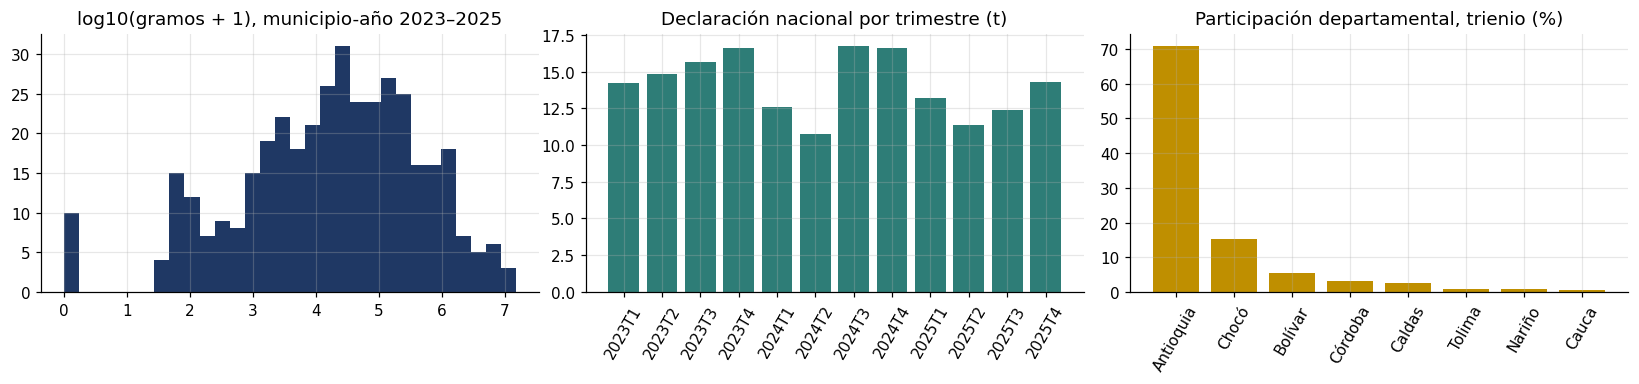

In [4]:
# Concentración y descriptivas en la ventana
tri = w_ma.groupby(["codigo_dane", "nombre_municipio"], as_index=False).agg(gramos=("gramos", "sum"), regalias_cop=("regalias_cop", "sum"), anios=("anio", "nunique"))
tri["t"] = tri.gramos / 1e6; tri["departamento"] = tri.codigo_dane.str[:2].map(DEPTOS); tri = tri.sort_values("gramos", ascending=False)
dep = tri.groupby("departamento").gramos.sum().sort_values(ascending=False); dep_pct = dep / dep.sum() * 100
print(f"Trienio 2023–2025: {tri.gramos.sum() / 1e6:,.1f} t en {(tri.gramos > 0).sum()} municipios con gramos de {(dep > 0).sum()} departamentos")
print("Participación departamental (%):"); display(dep_pct.round(1).head(6).to_frame("pct"))
print(f"Top-10 municipios = {tri.gramos.head(10).sum() / tri.gramos.sum() * 100:.1f} % del trienio; municipios con menos de 1 t en los tres años: {(tri.gramos < 1e6).sum()} de {len(tri)}")
display(tri.head(10)[["codigo_dane", "nombre_municipio", "departamento", "t", "regalias_cop", "anios"]])
cifra("1.3", "total del trienio (t)", 169, tri.gramos.sum() / 1e6, abs_tol=0.5); cifra("1.3", "departamentos con declaración", 18, (dep > 0).sum(), abs_tol=0)
cifra("1.3", "Antioquia (% del trienio)", 71, dep_pct["Antioquia"], abs_tol=0.5); cifra("1.3", "Chocó (% del trienio)", 15, dep_pct["Chocó"], abs_tol=0.5); cifra("1.3", "Bolívar (% del trienio)", 5, dep_pct["Bolívar"], abs_tol=0.5)
cifra("1.3", "top-10 municipios (% del trienio)", 71, tri.gramos.head(10).sum() / tri.gramos.sum() * 100, abs_tol=0.5)
for n, d in [("Caucasia", 35.6), ("Buritica", 24.6), ("Segovia", 16.8), ("El Bagre", 13.1), ("Remedios", 7.8)]:
    cifra("1.3", f"{n} 2023–2025 (t)", d, tri.loc[tri.nombre_municipio == n, "t"].iloc[0])
cifra("1.3", "municipios con menos de 1 t en el trienio", 141, (tri.gramos < 1e6).sum(), abs_tol=0); cifra("1.3", "... de un total de", 167, len(tri), abs_tol=0)

display(tabla_resumen(w_ma, ["gramos", "regalias_cop", "n_trimestres"]))
fig, ax = plt.subplots(1, 3, figsize=(15, 3.6))
ax[0].hist(np.log10(w_ma.gramos + 1), bins=30, color=AZUL); ax[0].set_title("log10(gramos + 1), municipio-año 2023–2025")
q = w_mt.groupby(["anio", "trim"]).gramos.sum() / 1e6; ax[1].bar([f"{a}T{t}" for a, t in q.index], q.values, color=TEAL); ax[1].set_title("Declaración nacional por trimestre (t)"); ax[1].tick_params(axis="x", rotation=60)
ax[2].bar(dep_pct.index[:8], dep_pct.values[:8], color=DORADO); ax[2].set_title("Participación departamental, trienio (%)"); ax[2].tick_params(axis="x", rotation=60)
plt.tight_layout(); plt.show()

**Consistencia interna entre gramos y regalías.** La regalía del oro es el 4 % del valor de la producción (6 % para el aluvión en contratos de concesión), liquidada sobre un precio base que equivale al 80 % del precio internacional. Si eso se cumple, el cociente `regalías / (gramos × precio COP/g)` debe quedar cerca de 0,032 (0,048 en el caso del aluvión en concesión). Un municipio-trimestre muy lejos de ese valor apunta a un error de unidades, a regalías de otro periodo o a un régimen de liquidación distinto. La comprobación necesita el precio en pesos, que se construye en la sección 3, y por eso se ejecuta allí.

## 3. Factores económicos: precio internacional y tasa de cambio

Son variables nacionales: entran al panel como promedios trimestrales y anuales, iguales para todos los municipios. Aquí se comprueba que las dos series mensuales sean continuas y se recalculan los promedios que cita la sección 1.1 del documento.

,tipo,n_no_nulos,pct_nulos,n_unicos,ejemplo
mes,object,197,0.00,197,2010-01
precio_usd_onza,float64,197,0.00,197,"1,117.96"
fecha,datetime64[ns],197,0.00,197,2010-01-01 00:00:00


,tipo,n_no_nulos,pct_nulos,n_unicos,ejemplo
anio_mes,object,417,0.00,417,1991-12
trm_promedio,float64,417,0.00,417,630.12
n_dias,int64,417,0.00,9,21
fecha,datetime64[ns],417,0.00,417,1991-12-01 00:00:00


[OK     ] Precio mensual continuo, sin repetidos ni nulos
[OK     ] TRM mensual continua; solo el último mes parcial — meses con < 15 días: ['2026-08']
[OK     ] Todos los meses de precio tienen TRM; la ventana 2023–2025 está completa (36 meses)
Promedios anuales:


,precio_usd_onza,trm,precio_cop_gramo,meses
anio,,,,
2022,"1,800.60","4,258.30","245,657.60",12
2023,"1,942.70","4,324.20","269,878.10",12
2024,"2,387.70","4,074.80","313,908.00",12
2025,"3,441.50","4,051.80","445,999.50",12
2026,"4,787.40","3,683.80","566,994.20",5


,n,nulos,ceros,media,desv_est,cv,min,p5,p25,mediana,p75,p95,max,asimetria,curtosis
precio_usd_onza,36.00,0.00,0.00,"2,590.62",708.57,0.27,"1,854.54","1,908.97","1,990.12","2,374.66","3,041.85","4,065.55","4,309.23",0.94,-0.10
trm_promedio,36.00,0.00,0.00,"4,150.29",263.12,0.06,"3,779.76","3,847.70","3,948.74","4,067.24","4,261.79","4,716.97","4,796.64",0.98,0.44
precio_cop_gramo,36.00,0.00,0.00,"343,261.88","84,651.36",0.25,"246,886.93","253,793.63","269,010.79","307,027.93","406,065.48","499,123.87","526,118.81",0.66,-0.85


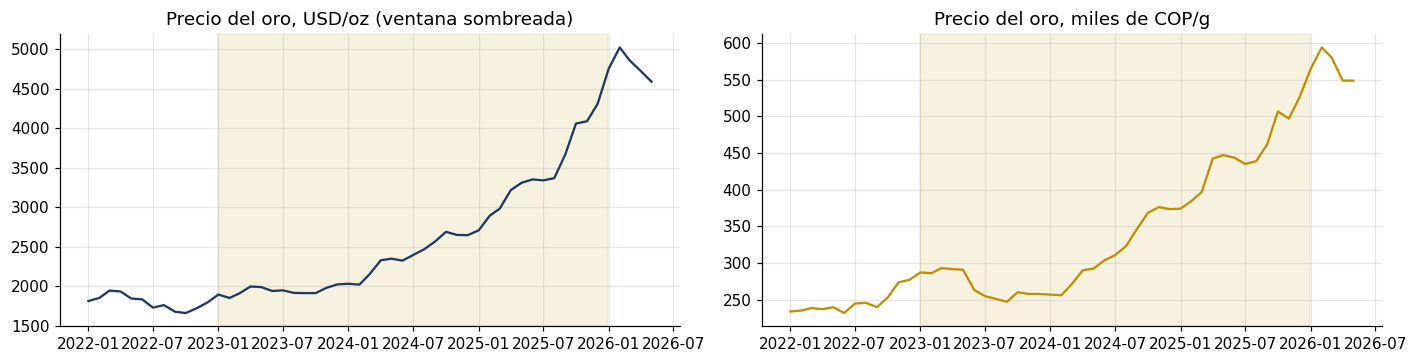

In [5]:
precio = pd.read_csv(RAIZ / "01_precio/precio_oro_mensual_usd_onza.csv"); trm_m = pd.read_csv(RAIZ / "01_precio/trm_mensual_promedio.csv")
precio["fecha"] = pd.to_datetime(precio.mes, format="%Y-%m"); trm_m["fecha"] = pd.to_datetime(trm_m.anio_mes, format="%Y-%m")
display(perfil(precio)); display(perfil(trm_m))
check("Económicos", "Precio mensual continuo, sin repetidos ni nulos", len(pd.date_range(precio.fecha.min(), precio.fecha.max(), freq="MS").difference(precio.fecha)) == 0
      and not precio.mes.duplicated().any() and precio.precio_usd_onza.notna().all())
check("Económicos", "TRM mensual continua; solo el último mes parcial", len(pd.date_range(trm_m.fecha.min(), trm_m.fecha.max(), freq="MS").difference(trm_m.fecha)) == 0
      and trm_m.loc[trm_m.n_dias < 15, "anio_mes"].tolist() in ([], [trm_m.anio_mes.iloc[-1]]), f"meses con < 15 días: {trm_m.loc[trm_m.n_dias < 15, 'anio_mes'].tolist()}")
pm = precio.merge(trm_m[["anio_mes", "trm_promedio"]], left_on="mes", right_on="anio_mes", how="left")
pm["precio_cop_gramo"] = pm.precio_usd_onza * pm.trm_promedio / ONZA_TROY_G; pm["anio"] = pm.fecha.dt.year; pm["trim"] = (pm.fecha.dt.month - 1) // 3 + 1
check("Económicos", "Todos los meses de precio tienen TRM; la ventana 2023–2025 está completa (36 meses)", pm.trm_promedio.notna().all() and pm.anio.isin(ANIOS).sum() == 36)

pa = pm.groupby("anio").agg(precio_usd_onza=("precio_usd_onza", "mean"), trm=("trm_promedio", "mean"), precio_cop_gramo=("precio_cop_gramo", "mean"), meses=("mes", "size"))
pt = pm.groupby(["anio", "trim"], as_index=False).agg(precio_usd_onza=("precio_usd_onza", "mean"), trm=("trm_promedio", "mean"), precio_cop_gramo=("precio_cop_gramo", "mean"))
print("Promedios anuales:"); display(pa.loc[2022:2026].round(1))
display(tabla_resumen(pm[pm.anio.isin(ANIOS)], ["precio_usd_onza", "trm_promedio", "precio_cop_gramo"]))
for a, d in zip(ANIOS, [1943, 2388, 3442]):
    cifra("1.1", f"precio promedio {a} (USD/oz)", d, pa.loc[a, "precio_usd_onza"])
for a, d in zip(ANIOS, [4424, 4075, 4052]):
    cifra("1.1", f"TRM promedio {a}", d, pa.loc[a, "trm"])
cifra("1.1", "aumento del precio en USD 2023→2025 (%)", 77, (pa.loc[2025, "precio_usd_onza"] / pa.loc[2023, "precio_usd_onza"] - 1) * 100, abs_tol=0.5)
cifra("1.1", "aumento del precio en COP/g 2023→2025 (%)", 66, (pa.loc[2025, "precio_cop_gramo"] / pa.loc[2023, "precio_cop_gramo"] - 1) * 100, abs_tol=1)
cifra("Introducción", "primer mes por encima de 5.000 USD/oz", 2026.02, float(pm.loc[pm.precio_usd_onza > 5000, "mes"].iloc[0].replace("-", ".")), abs_tol=0)

fig, ax = plt.subplots(1, 2, figsize=(13, 3.4)); w = pm[pm.anio.between(2022, 2026)]
ax[0].plot(w.fecha, w.precio_usd_onza, color=AZUL); ax[0].axvspan(pd.Timestamp("2023-01-01"), pd.Timestamp("2025-12-31"), color=DORADO, alpha=0.12); ax[0].set_title("Precio del oro, USD/oz (ventana sombreada)")
ax[1].plot(w.fecha, w.precio_cop_gramo / 1000, color=DORADO); ax[1].axvspan(pd.Timestamp("2023-01-01"), pd.Timestamp("2025-12-31"), color=DORADO, alpha=0.12); ax[1].set_title("Precio del oro, miles de COP/g")
plt.tight_layout(); plt.show()

,n,nulos,ceros,media,desv_est,cv,min,p5,p25,mediana,p75,p95,max,asimetria,curtosis
tasa_implicita_2012_2026,"6,438.00",76.00,0.00,0.05,0.87,18.60,0.00,0.03,0.03,0.03,0.03,0.04,69.45,77.88,"6,172.38"
tasa_implicita_2023_2025,"1,194.00",0.00,0.00,0.05,0.27,5.32,0.00,0.02,0.03,0.03,0.03,0.05,8.44,25.77,758.89


[OK     ] Tasa implícita de regalía 2023–2025: mediana cerca de 0,032 y < 10 % de municipio-trimestres fuera de [0,016; 0,072] — mediana = 0.0314; fuera de rango 63 de 1194 (5.3 %)
Casos fuera de rango en la ventana (ordenados por tasa):


,codigo_dane,nombre_municipio,anio,trim,kg,regalias_cop,tasa_implicita
1792,05736,Segovia,2025,3,"1,761.97","1,952,261,553.48",0.00
1793,05736,Segovia,2025,4,"1,870.42","2,421,139,786.95",0.00
1791,05736,Segovia,2025,2,"1,485.69","2,269,984,199.93",0.00
1785,05736,Segovia,2023,4,"1,468.43","1,473,062,527.88",0.00
1786,05736,Segovia,2024,1,933.81,"973,949,322.51",0.00
1790,05736,Segovia,2025,1,"1,693.73","2,822,817,411.21",0.00
1784,05736,Segovia,2023,3,"1,416.90","1,593,570,398.46",0.00
220,05040,Anori,2025,1,146.09,"294,988,356.93",0.01
1789,05736,Segovia,2024,4,"1,419.51","2,918,592,156.37",0.01
221,05040,Anori,2025,2,207.24,"535,733,270.74",0.01


Municipios con tasa implícita mediana < 0,02 en 2023–2025 (régimen de liquidación distinto o error sistemático):


,,tasa_implicita
codigo_dane,nombre_municipio,
05736,Segovia,0.00
05212,Copacabana,0.01
05040,Anori,0.01
05674,San Vicente,0.02
05088,Bello,0.02


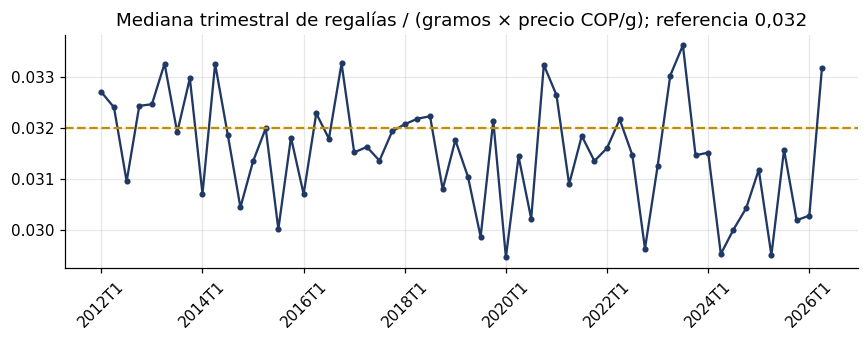

In [6]:
# Consistencia gramos ↔ regalías con el precio en pesos (toda la serie para contexto; detalle en la ventana)
c = anm_mt.merge(pt, on=["anio", "trim"], how="left"); c = c[c.gramos > 0].copy(); c["tasa_implicita"] = c.regalias_cop / (c.gramos * c.precio_cop_gramo)
cw = c[c.anio.isin(ANIOS)]
display(pd.concat([resumen_num(c.tasa_implicita, "tasa_implicita_2012_2026"), resumen_num(cw.tasa_implicita, "tasa_implicita_2023_2025")], axis=1).T)
fuera = cw[(cw.tasa_implicita < 0.016) | (cw.tasa_implicita > 0.072)]
check("ANM", "Tasa implícita de regalía 2023–2025: mediana cerca de 0,032 y < 10 % de municipio-trimestres fuera de [0,016; 0,072]",
      abs(cw.tasa_implicita.median() - 0.032) < 0.008 and len(fuera) / len(cw) < 0.10, f"mediana = {cw.tasa_implicita.median():.4f}; fuera de rango {len(fuera)} de {len(cw)} ({len(fuera) / len(cw) * 100:.1f} %)")
cols = ["codigo_dane", "nombre_municipio", "anio", "trim", "kg", "regalias_cop", "tasa_implicita"]
print("Casos fuera de rango en la ventana (ordenados por tasa):"); display(fuera.assign(kg=fuera.gramos / 1e3).sort_values("tasa_implicita")[cols].head(12))
pers = cw.groupby(["codigo_dane", "nombre_municipio"]).tasa_implicita.median()
print("Municipios con tasa implícita mediana < 0,02 en 2023–2025 (régimen de liquidación distinto o error sistemático):"); display(pers[pers < 0.02].sort_values().to_frame())
fig, ax = plt.subplots(figsize=(8, 3.2)); med = c.groupby(["anio", "trim"]).tasa_implicita.median().reset_index()
ax.plot(range(len(med)), med.tasa_implicita, marker="o", ms=3, color=AZUL); ax.axhline(0.032, ls="--", color=DORADO)
ax.set_xticks(range(0, len(med), 8)); ax.set_xticklabels([f"{a}T{t}" for a, t in zip(med.anio[::8], med.trim[::8])], rotation=45); ax.set_title("Mediana trimestral de regalías / (gramos × precio COP/g); referencia 0,032")
plt.tight_layout(); plt.show()

## 4. Factores institucionales: composición por tipo de explotador y barequeros frente a su tope legal

**4.1 Producción por tipo de explotador (UNODC–SIMCI).** Es la misma declaración de la ANM, desagregada por figura legal. Para 2021–2023 la capa trae a la vez el consolidado anual y los trimestres, que no se pueden sumar entre sí. Se usa solo el consolidado anual y se contrasta con la ANM de la sección 2, que es una descarga independiente de la misma declaración.

,tipo,n_no_nulos,pct_nulos,n_unicos,ejemplo
anio,object,3615,0.00,9,2017
trimestre,object,3615,0.00,5,Consolidado anual
codigo_municipio,object,3615,0.00,237,05002
explotador,object,3615,0.00,7,BAREQUEROS
gramos_oro,object,3615,0.00,3395,232.91417792


trimestre  Consolidado anual    I   II  III   IV
anio                                            
2017                     278    0    0    0    0
2018                     169    0    0    0    0
2019                     199    0    0    0    0
2020                     226    0    0    0    0
2021                     245  188  188  140  177
2022                     253  186  168  186  206
2023                     239  187    0    0    0
2024                     203    0    0    0    0
2025                     177    0    0    0    0
[OK     ] SIMCI: gramos numéricos sin nulos ni negativos; códigos de 5 dígitos válidos
Filas repetidas municipio-año-explotador: 23 (años [2024, 2025]); son partes de un mismo total y se suman. Filas '(en blanco)': 1 con 0 g
[OK     ] SIMCI: filas repetidas solo en 2024–2025 (se agregan sumando) — 23 filas
Toneladas por tipo de explotador (serie completa):


explotador,(en blanco),ARE,BAREQUEROS,CHATARREROS,SOLICITUDES DE LEGALIZACIÓN,SUBCONTRATOS DE FORMALIZACIÓN,TÍTULOS MINEROS,TOTAL
anio,,,,,,,,
2017,0.00,0.80,19.35,0.26,0.94,0.72,20.81,42.88
2018,0.00,0.72,15.89,0.58,0.31,1.13,17.32,35.96
2019,0.00,0.88,15.34,0.79,0.50,2.95,17.57,38.03
2020,0.00,0.93,19.38,0.60,2.01,5.79,19.85,48.56
2021,0.00,1.02,27.84,0.12,0.83,2.46,23.27,55.53
2022,0.00,0.74,26.96,0.04,0.67,1.40,25.43,55.23
2023,0.00,0.35,33.48,0.00,1.06,1.38,25.88,62.15
2024,0.00,0.32,29.01,0.00,1.47,1.21,24.71,56.71
2025,0.00,0.24,22.74,0.00,1.05,0.40,26.70,51.15


Participación (%):


explotador,(en blanco),ARE,BAREQUEROS,CHATARREROS,SOLICITUDES DE LEGALIZACIÓN,SUBCONTRATOS DE FORMALIZACIÓN,TÍTULOS MINEROS
anio,,,,,,,
2017,0.00,1.90,45.10,0.60,2.20,1.70,48.50
2018,0.00,2.00,44.20,1.60,0.90,3.10,48.20
2019,0.00,2.30,40.30,2.10,1.30,7.80,46.20
2020,0.00,1.90,39.90,1.20,4.10,11.90,40.90
2021,0.00,1.80,50.10,0.20,1.50,4.40,41.90
2022,0.00,1.30,48.80,0.10,1.20,2.50,46.00
2023,0.00,0.60,53.90,0.00,1.70,2.20,41.60
2024,0.00,0.60,51.10,0.00,2.60,2.10,43.60
2025,0.00,0.50,44.50,0.00,2.10,0.80,52.20


,ANM_t,SIMCI_t,dif_t,dif_pct
anio,,,,
2017,43.26,42.88,-0.38,-0.87
2018,35.99,35.96,-0.03,-0.09
2019,38.28,38.03,-0.24,-0.63
2020,49.53,48.56,-0.97,-1.95
2021,58.11,55.53,-2.58,-4.43
2022,54.72,55.23,0.52,0.95
2023,61.34,62.15,0.82,1.33
2024,56.73,56.71,-0.02,-0.03
2025,51.15,51.15,-0.01,-0.01


[OK     ] SIMCI reproduce el total ANM en 2023–2025 (|dif| < 1 t, como afirma la sección 4 del documento) — máx |dif| ventana = 0.82 t (serie completa: 2021 difiere -2.58 t)

Cruce municipio-año 2023–2025: {'both': 372, 'left_only': 16, 'right_only': 1} | pares con |dif| > 1 kg: 36


,codigo_dane,nombre_municipio,anio,gramos,g_simci,dif_g
130,13074,Barranco de Loba,2024,"291,166.71","285,368.76","-5,797.95"
83,05604,Remedios,2023,"3,237,675.51","3,234,047.42","-3,628.09"
32,05138,Cañasgordas,2024,"311,896.93","308,856.07","-3,040.86"
164,13688,Santa Rosa del Sur,2024,"3,920.73","1,045.56","-2,875.17"
55,05250,El Bagre,2024,"4,162,878.33","4,160,172.79","-2,705.54"
165,13688,Santa Rosa del Sur,2025,"23,101.50","20,507.50","-2,594.00"
78,05579,Puerto Berrio,2024,"185,739.37","183,919.58","-1,819.79"
46,05234,Dabeiba,2023,"454,907.15","453,200.25","-1,706.90"


[OK     ] Municipio-años 2023–2025 presentes en una sola fuente < 5 % — 4.4 % (17 de 389)


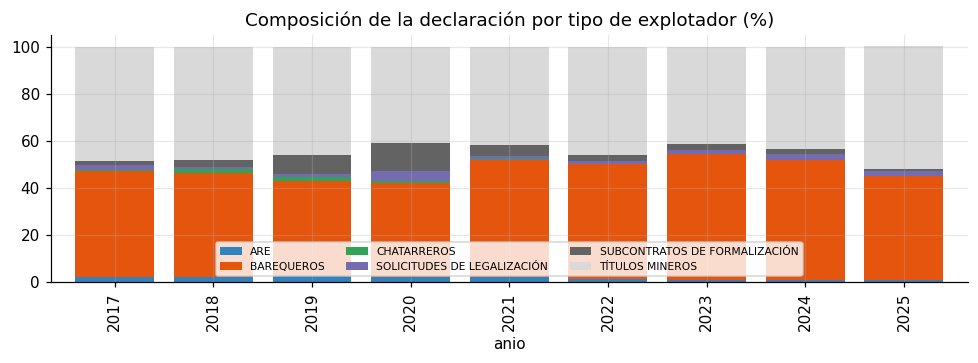

In [7]:
ex_raw = pd.read_csv(RAIZ / "09_produccion_explotador/produccion_oro_municipal_explotador_simci_2017_2025.csv", dtype=str)
display(perfil(ex_raw)); print(pd.crosstab(ex_raw.anio, ex_raw.trimestre))
ex = ex_raw[ex_raw.trimestre == "Consolidado anual"].copy(); ex["gramos"] = pd.to_numeric(ex.gramos_oro, errors="coerce"); ex["anio"] = ex.anio.astype(int); ex["codigo_municipio"] = ex.codigo_municipio.str.zfill(5)
check("Institucionales", "SIMCI: gramos numéricos sin nulos ni negativos; códigos de 5 dígitos válidos", ex.gramos.notna().all() and (ex.gramos >= 0).all() and (ex.codigo_municipio.str.len() == 5).all() and ex.codigo_municipio.str[:2].isin(DEPTOS).all())
rep = ex[ex.duplicated(["codigo_municipio", "anio", "explotador"], keep=False)]
print(f"Filas repetidas municipio-año-explotador: {len(rep)} (años {sorted(rep.anio.unique().tolist())}); son partes de un mismo total y se suman. Filas '(en blanco)': {(ex.explotador == '(en blanco)').sum()} con {ex.loc[ex.explotador == '(en blanco)', 'gramos'].sum():.0f} g")
check("Institucionales", "SIMCI: filas repetidas solo en 2024–2025 (se agregan sumando)", set(rep.anio.unique()) <= {2024, 2025}, f"{len(rep)} filas")

comp = ex.pivot_table(index="anio", columns="explotador", values="gramos", aggfunc="sum", fill_value=0) / 1e6; comp["TOTAL"] = comp.sum(axis=1)
part = (comp.drop(columns="TOTAL").div(comp.TOTAL, axis=0) * 100).round(1)
print("Toneladas por tipo de explotador (serie completa):"); display(comp.round(2)); print("Participación (%):"); display(part)
cruce = pd.DataFrame({"ANM_t": anm_ma.groupby("anio").gramos.sum() / 1e6, "SIMCI_t": comp.TOTAL}).dropna(); cruce["dif_t"] = cruce.SIMCI_t - cruce.ANM_t; cruce["dif_pct"] = cruce.dif_t / cruce.ANM_t * 100
display(cruce.round(3))
check("Institucionales", "SIMCI reproduce el total ANM en 2023–2025 (|dif| < 1 t, como afirma la sección 4 del documento)", (cruce.loc[ANIOS, "dif_t"].abs() < 1).all(), f"máx |dif| ventana = {cruce.loc[ANIOS, 'dif_t'].abs().max():.2f} t (serie completa: 2021 difiere {cruce.loc[2021, 'dif_t']:.2f} t)")
for a, b, t in [(2023, 33.5, 25.9), (2024, 29.0, 24.7), (2025, 22.7, 26.7)]:
    cifra("1.3", f"barequeros {a} (t)", b, comp.loc[a, "BAREQUEROS"]); cifra("1.3", f"títulos mineros {a} (t)", t, comp.loc[a, "TÍTULOS MINEROS"])

# Cruce municipio-año en la ventana
ex_ma = ex[ex.anio.isin(ANIOS)].groupby(["codigo_municipio", "anio"], as_index=False).gramos.sum().rename(columns={"codigo_municipio": "codigo_dane", "gramos": "g_simci"})
cm = w_ma.merge(ex_ma, on=["codigo_dane", "anio"], how="outer", indicator=True); amb = cm[cm._merge == "both"].copy(); amb["dif_g"] = amb.g_simci - amb.gramos
print(f"\nCruce municipio-año 2023–2025: {cm._merge.value_counts().to_dict()} | pares con |dif| > 1 kg: {(amb.dif_g.abs() > 1000).sum()}")
display(amb.loc[amb.dif_g.abs() > 1000, ["codigo_dane", "nombre_municipio", "anio", "gramos", "g_simci", "dif_g"]].sort_values("dif_g").head(8))
check("Institucionales", "Municipio-años 2023–2025 presentes en una sola fuente < 5 %", (cm._merge != "both").mean() < 0.05, f"{(cm._merge != 'both').mean() * 100:.1f} % ({(cm._merge != 'both').sum()} de {len(cm)})")
fig, ax = plt.subplots(figsize=(9, 3.4)); part.loc[2017:2025].drop(columns="(en blanco)", errors="ignore").plot(kind="bar", stacked=True, ax=ax, colormap="tab20c", width=0.8)
ax.set_title("Composición de la declaración por tipo de explotador (%)"); ax.legend(fontsize=7, ncol=3, loc="lower center"); plt.tight_layout(); plt.show()

**4.2 Barequeros inscritos (RUCOM) y tope legal.** El padrón es una fotografía del registro vigente, no una serie, y el municipio donde se inscribe el barequero puede no ser el municipio donde vende el oro; el documento fija los dos límites y aquí se mantienen. La variable institucional que sale de esta fuente es el contraste entre lo que un municipio declara por barequeo y el tope de 35 g al mes por inscrito (420 g al año), definido en la sección 2 del documento. Se recalculan sus cifras para 2023.

In [8]:
rb = pd.read_csv(RAIZ / "04_rucom/rucom_barequeros_metales_preciosos_municipio.csv", dtype={"codigo_dane": str})
display(perfil(rb)); display(resumen_num(rb.n_barequeros).to_frame().T)
check("Institucionales", "RUCOM: código de 5 dígitos válido, único por municipio, sin nulos ni ceros", (rb.codigo_dane.str.len() == 5).all() and rb.codigo_dane.str[:2].isin(DEPTOS).all() and not rb.codigo_dane.duplicated().any() and (rb.n_barequeros > 0).all())
print(f"Inscritos: {rb.n_barequeros.sum():,} en {len(rb)} municipios; los 5 primeros concentran {rb.nlargest(5, 'n_barequeros').n_barequeros.sum() / rb.n_barequeros.sum() * 100:.1f} %"); display(rb.nlargest(6, "n_barequeros"))
cifra("Introducción / 1.3", "barequeros inscritos", 74013, rb.n_barequeros.sum(), abs_tol=0); cifra("Introducción / 1.3", "municipios con inscritos", 174, len(rb), abs_tol=0)

bq = ex[ex.explotador == "BAREQUEROS"].groupby(["codigo_municipio", "anio"], as_index=False).gramos.sum().rename(columns={"codigo_municipio": "codigo_dane", "gramos": "g_barequeros"})
bq = bq.merge(rb[["codigo_dane", "n_barequeros"]], on="codigo_dane", how="left").fillna({"n_barequeros": 0})
bq["tope_g"] = bq.n_barequeros * TOPE_BAREQ_G_ANIO; bq["ratio_tope"] = np.where(bq.n_barequeros > 0, bq.g_barequeros / bq.tope_g, np.nan)
res = []
for a in ANIOS:
    b = bq[(bq.anio == a) & (bq.g_barequeros > 0)]
    res.append((a, len(b), int((b.ratio_tope > 1).sum()), int((b.n_barequeros == 0).sum()), b.loc[b.ratio_tope > 1, "g_barequeros"].sum() / 1e3, b.loc[b.n_barequeros == 0, "g_barequeros"].sum() / 1e3))
res = pd.DataFrame(res, columns=["anio", "municipios_con_barequeo", "superan_tope", "sin_inscritos", "kg_sobre_tope_munis", "kg_sin_inscritos"]); display(res)
cifra("1.4 / 2", "municipios con barequeo declarado 2023", 106, res.loc[0, "municipios_con_barequeo"], abs_tol=0); cifra("1.4 / 2", "... que superan el tope de sus inscritos", 42, res.loc[0, "superan_tope"], abs_tol=0)
cifra("1.4 / 2", "... sin ningún inscrito", 29, res.loc[0, "sin_inscritos"], abs_tol=0)
print("Mayores cocientes barequeo declarado / tope de inscritos, 2023–2025:")
display(bq[bq.anio.isin(ANIOS)].nlargest(8, "ratio_tope").merge(anm.groupby("codigo_dane").nombre_municipio.first(), on="codigo_dane", how="left")[["codigo_dane", "nombre_municipio", "anio", "g_barequeros", "n_barequeros", "ratio_tope"]])

,tipo,n_no_nulos,pct_nulos,n_unicos,ejemplo
codigo_dane,object,174,0.00,174,05004
departamento,object,174,0.00,22,ANTIOQUIA
municipio,object,174,0.00,172,ABRIAQUÍ
n_barequeros,int64,174,0.00,78,14


,n,nulos,ceros,media,desv_est,cv,min,p5,p25,mediana,p75,p95,max,asimetria,curtosis
n_barequeros,174.00,0.00,0.00,425.36,"2,434.87",5.72,1.00,1.00,4.00,14.50,51.00,"1,517.05","29,209.00",10.17,115.56


[OK     ] RUCOM: código de 5 dígitos válido, único por municipio, sin nulos ni ceros
Inscritos: 74,013 en 174 municipios; los 5 primeros concentran 73.4 %


,codigo_dane,departamento,municipio,n_barequeros
10,05154,ANTIOQUIA,CAUCASIA,29209
95,27810,CHOCO,UNIÓN PANAMERICANA ( Animas),9386
86,27413,CHOCO,LLORÓ,8077
76,23682,CORDOBA,SAN JOSE DE URE,4716
88,27450,CHOCO,MEDIO SAN JUAN (Andagoya),2955
39,13006,BOLIVAR,ACHÍ,1992


,anio,municipios_con_barequeo,superan_tope,sin_inscritos,kg_sobre_tope_munis,kg_sin_inscritos
0,2023,106,42,29,"11,166.61","6,143.70"
1,2024,83,27,20,"20,180.23","1,932.26"
2,2025,65,14,16,"4,425.08",741.01


Mayores cocientes barequeo declarado / tope de inscritos, 2023–2025:


,codigo_dane,nombre_municipio,anio,g_barequeros,n_barequeros,ratio_tope
0,27491,Novita,2023,"1,840,876.60",12.00,365.25
1,27491,Novita,2024,"800,780.47",12.00,158.89
2,94001,Inirida,2023,"59,886.25",1.00,142.59
3,05579,Puerto Berrio,2023,"194,121.91",4.00,115.55
4,05579,Puerto Berrio,2024,"101,411.00",4.00,60.36
5,27745,Sipi,2023,"577,309.46",26.00,52.87
6,05190,Cisneros,2023,"39,771.25",2.00,47.35
7,05190,Cisneros,2024,"25,422.86",2.00,30.27


## 5. Factores estructurales: huella EVOA y su condición jurídica

La huella de explotación aluvial llega hasta 2023, de modo que el documento la trata como característica estructural del municipio y no como serie anual. Primero se verifica la capa completa (años disponibles, sumas de municipio a departamento y a nación, clases de figura de ley) y después se fijan las variables estructurales: huella en 2023, promedio 2021–2023, proporción sin figura de ley y tipo de minería predominante, que combina el explotador dominante con la huella.

In [9]:
ev = pd.read_csv(RAIZ / "03_evoa/arcgis_simci/01_evoa_municipio_ha_2014_2023.csv", dtype={"codigo_municipio": str, "codigo_departamento": str}, encoding="utf-8-sig")
evd = pd.read_csv(RAIZ / "03_evoa/arcgis_simci/02_evoa_departamento_ha_2014_2023.csv", dtype={"codigo_departamento": str}, encoding="utf-8-sig")
evn = pd.read_csv(RAIZ / "03_evoa/evoa_nacional_serie_informes.csv")
evf = pd.read_csv(RAIZ / "03_evoa/arcgis_simci/05_evoa_municipio_clases_figura_ley_2021_2023.csv", dtype={"codigo_municipio": str, "codigo_departamento": str}, encoding="utf-8-sig")
evg = pd.read_csv(RAIZ / "03_evoa/evoa_municipal_2018_2020.csv", dtype=str)
display(perfil(ev)); print("Años disponibles:", sorted(ev.anio.unique().tolist()))
check("Estructurales", "EVOA: códigos válidos, sin duplicados municipio-año, sin nulos ni negativos, departamento coherente con el código",
      (ev.codigo_municipio.str.len() == 5).all() and ev.codigo_departamento.isin(DEPTOS).all() and not ev.duplicated(["codigo_municipio", "anio"]).any() and ev.evoa_ha.notna().all()
      and (ev.evoa_ha >= 0).all() and (ev.codigo_departamento.map(DEPTOS).apply(normaliza) == ev.departamento.apply(normaliza)).all())
cmp = pd.DataFrame({"suma_municipal": ev.groupby("anio").evoa_ha.sum(), "suma_departamental": evd.groupby("anio").evoa_ha.sum(), "serie_nacional_informes": evn.set_index("anio").evoa_tierra_ha})
cmp["dif_mun_dep"] = cmp.suma_municipal - cmp.suma_departamental; cmp["dif_mun_nac"] = cmp.suma_municipal - cmp.serie_nacional_informes; display(cmp.round(1))
check("Estructurales", "EVOA: suma municipal = departamental = serie nacional (|dif| < 1 ha)", (cmp.dif_mun_dep.abs() < 1).all() and (cmp.dif_mun_nac.dropna().abs() < 1).all())
evf["suma_clases"] = evf.hectareas_con_permisos + evf.hectareas_en_transito_a + evf.hectareas_explotacion_ilicita
mf = evf.merge(ev[["codigo_municipio", "anio", "evoa_ha"]], on=["codigo_municipio", "anio"], how="left")
check("Estructurales", "Figuras de ley 2021–2023: permisos + tránsito + ilícita = total = evoa_ha municipal", ((evf.suma_clases - evf.total_evidencia_explotacion).abs() < 0.01).all() and ((mf.total_evidencia_explotacion - mf.evoa_ha).abs() < 0.01).all())
evg["codigo_municipio"] = evg.codigo_municipio.str.zfill(5); evg["anio"] = evg.a_o.astype(int); evg["total"] = pd.to_numeric(evg.total_evidencia_explotacion)
mg = evg.merge(ev[ev.anio.between(2018, 2020)], on=["codigo_municipio", "anio"], how="outer", indicator=True); amb_g = mg[mg._merge == "both"]
check("Estructurales", "El servicio ArcGIS reproduce datos.gov.co 2018–2020 (control de la extracción)", (mg._merge == "left_only").sum() == 0 and ((mg._merge == "right_only") & (mg.evoa_ha > 0)).sum() == 0 and ((amb_g.total - amb_g.evoa_ha).abs() < 0.01).all(),
      f"máx |dif| = {(amb_g.total - amb_g.evoa_ha).abs().max():.4f} ha; ArcGIS añade {(mg._merge == 'right_only').sum()} municipio-años con 0 ha")

# Cifras del documento (1.3 y 1.4)
e23 = ev[ev.anio == 2023].copy(); e22 = ev[ev.anio == 2022]
clases = evf.groupby("anio")[["hectareas_con_permisos", "hectareas_en_transito_a", "hectareas_explotacion_ilicita"]].sum(); clases_pct = clases.div(clases.sum(axis=1), axis=0) * 100
print("Participación nacional por figura de ley (%):"); display(clases_pct.round(1))
cifra("1.3 / 1.4", "huella EVOA 2023 (ha)", 105060, e23.evoa_ha.sum()); cifra("1.3", "variación 2023 vs 2022 (%)", 11, (e23.evoa_ha.sum() / e22.evoa_ha.sum() - 1) * 100, abs_tol=0.5)
cifra("1.3", "Antioquia + Chocó (% de la huella 2023)", 77, e23[e23.codigo_departamento.isin(["05", "27"])].evoa_ha.sum() / e23.evoa_ha.sum() * 100, abs_tol=0.5)
cifra("1.4", "huella sin figura de ley 2023 (%)", 76, clases_pct.loc[2023, "hectareas_explotacion_ilicita"], abs_tol=0.5); cifra("1.4", "huella sin figura de ley 2023 (ha)", 79600, clases.loc[2023, "hectareas_explotacion_ilicita"], abs_tol=50)
for n, d in [("Zaragoza", 8669), ("Nechí", 8152)]:
    cifra("1.3", f"huella {n} 2023 (ha)", d, e23.loc[e23.municipio == n, "evoa_ha"].iloc[0])
print(f"Municipios en la capa 2023: {len(e23)}; con huella > 0: {(e23.evoa_ha > 0).sum()}; en los tres años 2021–2023 con huella > 0: {(ev[ev.anio >= 2021].groupby('codigo_municipio').evoa_ha.min() > 0).sum()}")
display(tabla_resumen(e23[e23.evoa_ha > 0], ["evoa_ha"]))

,tipo,n_no_nulos,pct_nulos,n_unicos,ejemplo
anio,int64,1388,0.00,8,2014
codigo_departamento,object,1388,0.00,19,05
departamento,object,1388,0.00,19,Antioquia
codigo_municipio,object,1388,0.00,178,05031
municipio,object,1388,0.00,175,Amalfi
evoa_ha,float64,1388,0.00,876,807.20


Años disponibles: [2014, 2016, 2018, 2019, 2020, 2021, 2022, 2023]
[OK     ] EVOA: códigos válidos, sin duplicados municipio-año, sin nulos ni negativos, departamento coherente con el código


,suma_municipal,suma_departamental,serie_nacional_informes,dif_mun_dep,dif_mun_nac
anio,,,,,
2014,"78,939.00","78,939.00",78939,0.00,0.00
2016,"83,620.30","83,620.30",83620,0.00,0.30
2018,"92,046.10","92,046.10",92046,0.00,0.10
2019,"98,027.60","98,027.60",98028,0.00,-0.40
2020,"100,751.60","100,751.60",100752,0.00,-0.40
2021,"98,567.10","98,567.10",98567,0.00,0.10
2022,"94,733.00","94,733.00",94733,0.00,0.00
2023,"105,059.80","105,059.80",105060,-0.00,-0.20


[OK     ] EVOA: suma municipal = departamental = serie nacional (|dif| < 1 ha)
[OK     ] Figuras de ley 2021–2023: permisos + tránsito + ilícita = total = evoa_ha municipal


[OK     ] El servicio ArcGIS reproduce datos.gov.co 2018–2020 (control de la extracción) — máx |dif| = 0.0001 ha; ArcGIS añade 218 municipio-años con 0 ha
Participación nacional por figura de ley (%):


,hectareas_con_permisos,hectareas_en_transito_a,hectareas_explotacion_ilicita
anio,,,
2021,28.80,6.20,64.90
2022,21.40,5.60,73.00
2023,19.70,4.50,75.80


Municipios en la capa 2023: 178; con huella > 0: 101; en los tres años 2021–2023 con huella > 0: 97


,n,nulos,ceros,media,desv_est,cv,min,p5,p25,mediana,p75,p95,max,asimetria,curtosis
evoa_ha,101.00,0.00,0.00,"1,040.20","1,814.96",1.74,3.08,7.16,38.55,196.30,"1,233.32","5,541.27","8,668.76",2.46,5.86


[OK     ] Variables estructurales: una fila por municipio, ilícita ≤ total, share en [0, 1]


,n,nulos,ceros,media,desv_est,cv,min,p5,p25,mediana,p75,p95,max,asimetria,curtosis
evoa_ha_2023,101.00,0.00,0.00,"1,040.20","1,814.96",1.74,3.08,7.16,38.55,196.30,"1,233.32","5,541.27","8,668.76",2.46,5.86
evoa_ha_prom_2021_2023,101.00,0.00,0.00,984.50,"1,700.14",1.73,2.39,4.23,36.54,171.11,"1,347.96","4,840.88","8,062.18",2.43,5.83
ha_ilicita_2023,101.00,0.00,0.00,788.43,"1,329.30",1.69,0.36,3.83,31.24,162.75,"1,040.68","4,256.89","6,351.12",2.43,5.77
share_ilicita_2023,101.00,0.00,0.00,0.85,0.23,0.27,0.02,0.42,0.73,0.97,1.00,1.00,1.00,-1.84,3.24
var_huella_2021_2023_pct,93.00,8.00,0.00,37.54,115.34,3.07,-66.94,-35.15,-5.96,7.97,45.65,142.97,723.27,4.74,26.03


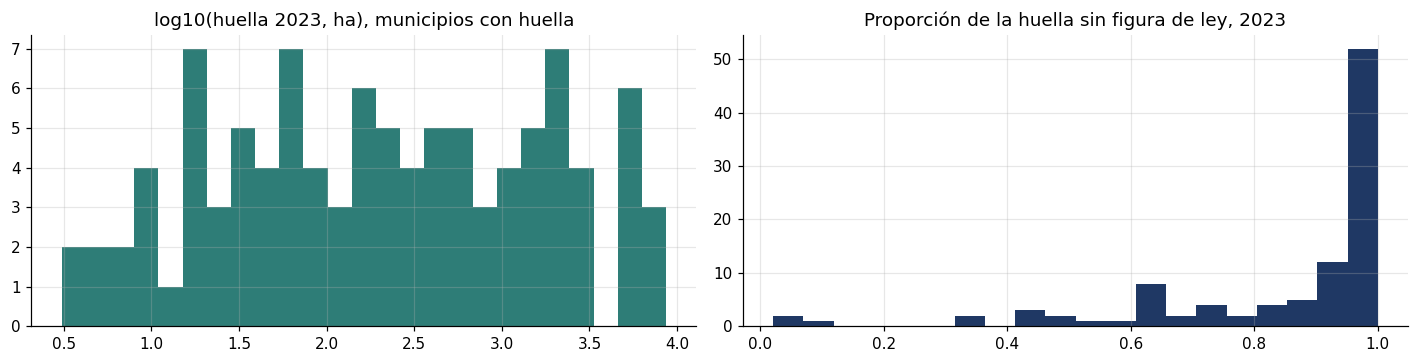

In [10]:
# Variables estructurales por municipio (invariantes en la ventana)
est = ev[ev.anio.between(2021, 2023)].pivot(index="codigo_municipio", columns="anio", values="evoa_ha").fillna(0)
est = pd.DataFrame({"evoa_ha_2023": est[2023], "evoa_ha_prom_2021_2023": est.mean(axis=1), "evoa_ha_2021": est[2021]})
f23 = evf[evf.anio == 2023].set_index("codigo_municipio")
est["ha_permisos_2023"] = f23.hectareas_con_permisos; est["ha_transito_2023"] = f23.hectareas_en_transito_a; est["ha_ilicita_2023"] = f23.hectareas_explotacion_ilicita
est[["ha_permisos_2023", "ha_transito_2023", "ha_ilicita_2023"]] = est[["ha_permisos_2023", "ha_transito_2023", "ha_ilicita_2023"]].fillna(0)
est["share_ilicita_2023"] = np.where(est.evoa_ha_2023 > 0, (est.ha_ilicita_2023 / est.evoa_ha_2023).clip(upper=1.0), np.nan)   # clip: diferencias de 1e-6 ha entre capas
est["var_huella_2021_2023_pct"] = np.where(est.evoa_ha_2021 > 0, (est.evoa_ha_2023 / est.evoa_ha_2021 - 1) * 100, np.nan)
est.index.name = "codigo_dane"; est = est.reset_index()
check("Estructurales", "Variables estructurales: una fila por municipio, ilícita ≤ total, share en [0, 1]", not est.codigo_dane.duplicated().any() and (est.ha_ilicita_2023 <= est.evoa_ha_2023 + 0.01).all() and est.share_ilicita_2023.dropna().between(0, 1).all())
display(tabla_resumen(est[est.evoa_ha_2023 > 0], ["evoa_ha_2023", "evoa_ha_prom_2021_2023", "ha_ilicita_2023", "share_ilicita_2023", "var_huella_2021_2023_pct"]))
fig, ax = plt.subplots(1, 2, figsize=(13, 3.4))
ax[0].hist(np.log10(est.loc[est.evoa_ha_2023 > 0, "evoa_ha_2023"]), bins=25, color=TEAL); ax[0].set_title("log10(huella 2023, ha), municipios con huella")
ax[1].hist(est.share_ilicita_2023.dropna(), bins=20, color=AZUL); ax[1].set_title("Proporción de la huella sin figura de ley, 2023"); plt.tight_layout(); plt.show()

## 6. Factores de seguridad y presencia estatal: operativos (MinDefensa, municipio × mes)

Minas intervenidas, capturas y maquinaria incautada son conteos de eventos. Un municipio-mes que no aparece tuvo cero operativos. Se valida el formato, se agrega a municipio × trimestre y a municipio × año, y se recalculan las cifras nacionales de la sección 1.4 del documento.

In [11]:
op = {}
for k, f, val in [("minas", "minas_intervenidas_municipal_mensual.csv", "minas"), ("capturas", "capturas_mineria_ilegal_municipal_mensual.csv", "capturas"), ("maquinaria", "incautaciones_maquinaria_municipal_mensual.csv", "cantidad")]:
    d = pd.read_csv(RAIZ / "08_operativos" / f, dtype=str); d["valor"] = pd.to_numeric(d[val], errors="coerce"); d["anio"] = d.anio.astype(int); d["mes"] = d.mes.astype(int)
    malos = d[(d.cod_muni.str.len() != 5) | ~d.cod_muni.str[:2].isin(DEPTOS)]; llave = ["cod_muni", "anio", "mes"] + (["clase_de_bien"] if k == "maquinaria" else [])
    print(f"== {k}: {d.shape}, {d.anio.min()}–{d.anio.max()} (último mes de {d.anio.max()}: {d.loc[d.anio == d.anio.max(), 'mes'].max()}); en 2023–2025: {d.anio.isin(ANIOS).sum():,} filas, {d[d.anio.isin(ANIOS)].cod_muni.nunique()} municipios")
    check("Seguridad", f"{k}: numérico sin nulos ni negativos, mes 1–12, sin duplicados en {'+'.join(llave)}", d.valor.notna().all() and (d.valor >= 0).all() and d.mes.between(1, 12).all() and not d.duplicated(llave).any())
    check("Seguridad", f"{k}: todos los códigos de municipio válidos", len(malos) == 0, f"{len(malos)} filas con código inválido {malos.cod_muni.unique().tolist()} (se excluyen)")
    check("Seguridad", f"{k}: 2023, 2024 y 2025 con los 12 meses", all(d.loc[d.anio == a, "mes"].nunique() == 12 for a in ANIOS))
    op[k] = d[~d.index.isin(malos.index)]
op_ma = None; op_mt = None
for k, d in op.items():
    d = d.assign(trim=(d.mes - 1) // 3 + 1)
    g = d.groupby(["cod_muni", "anio"], as_index=False).valor.sum().rename(columns={"cod_muni": "codigo_dane", "valor": k}); op_ma = g if op_ma is None else op_ma.merge(g, on=["codigo_dane", "anio"], how="outer")
    gt = d.groupby(["cod_muni", "anio", "trim"], as_index=False).valor.sum().rename(columns={"cod_muni": "codigo_dane", "valor": k}); op_mt = gt if op_mt is None else op_mt.merge(gt, on=["codigo_dane", "anio", "trim"], how="outer")
op_ma = op_ma.fillna(0); op_mt = op_mt.fillna(0)
nac = op_ma.groupby("anio")[["minas", "capturas", "maquinaria"]].sum(); display(nac.loc[2019:2026].T)
for a, d in zip(ANIOS, [2969, 5247, 6151]):
    cifra("1.4", f"minas intervenidas {a}", d, nac.loc[a, "minas"], abs_tol=0)
w_op = op_ma[op_ma.anio.isin(ANIOS)]
print(f"Ventana 2023–2025: {w_op.codigo_dane.nunique()} municipios con algún operativo")
display(tabla_resumen(w_op, ["minas", "capturas", "maquinaria"]))
print("Maquinaria incautada por clase de bien, 2023–2025:"); display(op["maquinaria"][op["maquinaria"].anio.isin(ANIOS)].groupby("clase_de_bien").valor.sum().sort_values(ascending=False))

== minas: (9223, 5), 2010–2026 (último mes de 2026: 7); en 2023–2025: 3,360 filas, 535 municipios
[OK     ] minas: numérico sin nulos ni negativos, mes 1–12, sin duplicados en cod_muni+anio+mes
[OK     ] minas: todos los códigos de municipio válidos — 0 filas con código inválido [] (se excluyen)
[OK     ] minas: 2023, 2024 y 2025 con los 12 meses


== capturas: (5207, 5), 2010–2026 (último mes de 2026: 7); en 2023–2025: 858 filas, 311 municipios
[OK     ] capturas: numérico sin nulos ni negativos, mes 1–12, sin duplicados en cod_muni+anio+mes
[OK     ] capturas: todos los códigos de municipio válidos — 0 filas con código inválido [] (se excluyen)
[OK     ] capturas: 2023, 2024 y 2025 con los 12 meses
== maquinaria: (6089, 7), 2010–2026 (último mes de 2026: 7); en 2023–2025: 1,763 filas, 372 municipios
[OK     ] maquinaria: numérico sin nulos ni negativos, mes 1–12, sin duplicados en cod_muni+anio+mes+clase_de_bien
[REVISAR] maquinaria: todos los códigos de municipio válidos — 1 filas con código inválido ['760101'] (se excluyen)
[OK     ] maquinaria: 2023, 2024 y 2025 con los 12 meses


anio,2019,2020,2021,2022,2023,2024,2025,2026
minas,"3,752.00","4,487.00","3,893.00","2,413.00","2,969.00","5,247.00","6,151.00","4,616.00"
capturas,"1,542.00","1,935.00","1,815.00","1,214.00","1,193.00","1,148.00","1,439.00",954.00
maquinaria,948.00,"1,125.00","1,039.00","1,236.00","1,093.00","1,309.00","2,189.00","2,038.00"


Ventana 2023–2025: 648 municipios con algún operativo


,n,nulos,ceros,media,desv_est,cv,min,p5,p25,mediana,p75,p95,max,asimetria,curtosis
minas,"1,334.00",0.00,283.00,10.77,27.04,2.51,0.00,0.00,1.00,3.00,9.00,47.00,360.00,6.83,64.28
capturas,"1,334.00",0.00,843.00,2.83,6.96,2.46,0.00,0.00,0.00,0.00,3.00,14.00,67.00,4.67,28.38
maquinaria,"1,334.00",0.00,689.00,3.44,13.21,3.84,0.00,0.00,0.00,0.00,2.00,15.00,300.00,12.61,227.47


Maquinaria incautada por clase de bien, 2023–2025:


clase_de_bien
RETROEXCAVADORA - MINERIA      1116
DRAGA (MINERIA) - MINERIA      1088
DRAGA TIPO BUZO - MINERIA       987
EXCAVADORA - MINERIA            529
CLASIFICADORA - MINERIA         481
DRAGA TIPO DRAGON - MINERIA     248
BULDOZER - MINERIA               58
MEZCLADORA - MINERIA             51
TRITURADORA - MINERIA            33
Name: valor, dtype: int64

## 7. Señal nacional de brecha: exportaciones (UN Comtrade y DIAN vía Legiscomex)

Las declaraciones de exportación identifican a la empresa exportadora, no a la mina. Por eso el documento las usa como señal nacional de brecha entre lo exportado y lo declarado, y no como variable del panel. Aquí se validan las identidades entre subpartidas, la suma del microdato contra Comtrade año a año y los campos vacíos o confidenciales, y se recalculan la brecha y los destinos de 2023.

In [12]:
cs = pd.read_csv(RAIZ / "10_exportaciones/comtrade_oro_subpartidas_anual_2010_2025.csv"); css = pd.read_csv(RAIZ / "10_exportaciones/comtrade_oro_subpartidas_socios_2010_2025.csv")
ct = pd.read_csv(RAIZ / "10_exportaciones/comtrade_expo_oro_7108_anual_2010_2025.csv")
x = cs[cs.flujo == "X"].pivot_table(index="anio", columns="subpartida_hs6", values="peso_neto_kg", aggfunc="sum", fill_value=0); x["7108_total"] = ct.set_index("anio").peso_neto_kg
check("Exportaciones", "Comtrade: 710812 + 710813 = 7108 (|dif| ≤ 2 kg) y suma de socios = total mundial", ((x[710812] + x[710813] - x["7108_total"]).abs() <= 2).all()
      and ((lambda soc, tot: (soc - tot.reindex(soc.index)).abs() <= 2)(css[css.flujo == "X"].groupby(["anio", "subpartida_hs6"]).peso_neto_kg.sum(), cs[cs.flujo == "X"].set_index(["anio", "subpartida_hs6"]).peso_neto_kg)).all())
exp_t = x.loc[ANIOS, "7108_total"] / 1000; dec_t = serie.loc[ANIOS, "toneladas"]
brecha = pd.DataFrame({"exportado_7108_t": exp_t, "declarado_ANM_t": dec_t, "brecha_t": exp_t - dec_t, "brecha_pct": (exp_t / dec_t - 1) * 100}); display(brecha.round(2))
for a, d in zip(ANIOS, [71.1, 69.9, 57.2]):
    cifra("1.1", f"exportaciones de oro 7108 {a} (t)", d, brecha.loc[a, "exportado_7108_t"])
for a, d in zip(ANIOS, [17, 23, 12]):
    cifra("1.1 / 1.4", f"brecha exportado/declarado {a} (%)", d, brecha.loc[a, "brecha_pct"], abs_tol=0.5)
dest = css[(css.flujo == "X") & (css.subpartida_hs6.isin([710812, 710813])) & (css.anio == 2023)].groupby("socio").peso_neto_kg.sum().sort_values(ascending=False)
dest_pct = dest / dest.sum() * 100; print("Destinos 2023 (% del peso, 7108):"); display(dest_pct.head(6).round(1).to_frame("pct"))
for n, d in [("Estados Unidos", 34), ("Italia", 21), ("India", 12), ("Hong Kong", 11)]:
    k = [s for s in dest_pct.index if normaliza(n) in normaliza(s)]
    cifra("1.1", f"destino 2023: {n} (%)", d, dest_pct[k[0]] if k else np.nan, abs_tol=0.5)
zf = [s for s in dest_pct.index if "free" in s.lower() or "zona" in s.lower() or "franca" in s.lower()]
cifra("1.1", "destino 2023: zonas francas (%)", 12, dest_pct[zf].sum() if zf else np.nan, abs_tol=0.5)

[OK     ] Comtrade: 710812 + 710813 = 7108 (|dif| ≤ 2 kg) y suma de socios = total mundial


,exportado_7108_t,declarado_ANM_t,brecha_t,brecha_pct
anio,,,,
2023,71.70,61.33,10.37,16.91
2024,69.89,56.73,13.15,23.18
2025,57.16,51.15,6.01,11.74


Destinos 2023 (% del peso, 7108):


,pct
socio,
Estados Unidos,34.00
Italia,20.90
Zonas francas,12.40
India,12.30
Hong Kong,10.70
Emiratos Arabes Unidos,5.90


np.True_

In [13]:
# Legiscomex: microdato 2023–2025 (y 2017–2022, 2026 como contexto)
LG = RAIZ / "10_exportaciones/legiscomex"; partes = []
for f in sorted(LG.glob("legiscomex_expo_*.xlsx")):
    m = re.match(r"legiscomex_expo_(\d{10})_(\d{4})(_ene-jun)?\.xlsx", f.name); d = pd.read_excel(f, dtype=str)
    d["_subpartida"] = m.group(1); d["_anio_archivo"] = int(m.group(2)); partes.append(d)
lg = pd.concat(partes, ignore_index=True)
for c_ in ["Peso en kilos netos", "Valor FOB (USD)"]:
    lg[c_] = pd.to_numeric(lg[c_], errors="coerce")
lg["anio"] = pd.to_numeric(lg["Año"]); lg["mes"] = pd.to_numeric(lg["Mes"]); lg["hs6"] = lg._subpartida.str[:6].astype(int)
print("Legiscomex:", lg.shape, "| archivos:", len(partes), "| filas 2023–2025:", lg.anio.isin(ANIOS).sum())
check("Exportaciones", "Legiscomex: 18 archivos con 67 columnas; año y subpartida coinciden con el archivo; kg y FOB numéricos sin nulos", len(partes) == 18 and all(p.shape[1] == partes[0].shape[1] for p in partes)
      and (lg.anio == lg._anio_archivo).all() and (lg["Código Partida"] == lg._subpartida).all() and lg["Peso en kilos netos"].notna().all() and lg["Valor FOB (USD)"].notna().all())
lk = lg.groupby(["anio", "hs6"]).agg(kg_legiscomex=("Peso en kilos netos", "sum"), declaraciones=("Número de la declaración definitiva", "nunique"), exportadores=("NIT del exportador", "nunique")).reset_index()
val = lk.merge(cs[cs.flujo == "X"][["anio", "subpartida_hs6", "peso_neto_kg"]].rename(columns={"subpartida_hs6": "hs6", "peso_neto_kg": "kg_comtrade"}), on=["anio", "hs6"], how="left")
val["dif_pct"] = (val.kg_legiscomex / val.kg_comtrade - 1) * 100; display(val[val.anio.isin(ANIOS)].round(3))
v = val[val.hs6.isin([710812, 710813]) & (val.anio <= 2025)]
check("Exportaciones", "Legiscomex reproduce Comtrade en 710812/710813 (|dif| ≤ 0,1 %, como afirma la sección 4)", (v.dif_pct.abs() <= 0.1).all(), f"máx |dif| = {v.dif_pct.abs().max():.3f} %")

oro = lg[(lg.hs6 == 710812) & lg.anio.isin(ANIOS)].copy()
conf = oro["País de Destino"].str.contains("confidencial", case=False, na=False); pn = oro["Razón social actual Exportador"].str.strip().str.upper().eq("PERSONA NATURAL"); zfr = oro["País de Destino"].str.contains("ZONA FRANCA", case=False, na=False)
res = oro.assign(conf=conf, pn=pn, zf=zfr).groupby("anio").agg(filas=("anio", "size"), declaraciones=("Número de la declaración definitiva", "nunique"), exportadores=("NIT del exportador", "nunique"),
    destino_confidencial=("conf", "sum"), pct_persona_natural=("pn", "mean"), pct_kg_zona_franca=("Peso en kilos netos", lambda s: s[zfr.loc[s.index]].sum() / s.sum()), pct_descripcion_vacia=("Descripción de la Mercancía", lambda s: s.isna().mean()))
for c_ in ["pct_persona_natural", "pct_kg_zona_franca", "pct_descripcion_vacia"]:
    res[c_] = (res[c_] * 100).round(1)
display(res)
print("Domicilio del exportador (% filas) y departamento de origen (% kg), 2023–2025:")
display(pd.concat([(oro["Municipio"].value_counts(normalize=True) * 100).round(1).head(4).rename("domicilio_pct_filas"),
                   (oro.groupby("Departamento Origen")["Peso en kilos netos"].sum() / oro["Peso en kilos netos"].sum() * 100).sort_values(ascending=False).round(1).head(4).rename("origen_pct_kg")], axis=1))
ref = pm.assign(mes=pm.fecha.dt.month, usd_kg_ref=pm.precio_usd_onza / ONZA_TROY_G * 1000)[["anio", "mes", "usd_kg_ref"]]
oro = oro.merge(ref, on=["anio", "mes"], how="left"); oro["ratio_precio"] = oro["Valor FOB (USD)"] / oro["Peso en kilos netos"] / oro.usd_kg_ref
an = oro[(oro.ratio_precio < 0.3) | (oro.ratio_precio > 1.1)]
check("Exportaciones", "Legiscomex 2023–2025: < 2 % de declaraciones de oro en bruto con precio implícito fuera de [0,3; 1,1] × LBMA", len(an) / len(oro) < 0.02, f"{len(an)} de {len(oro):,} ({len(an) / len(oro) * 100:.2f} %); mediana del cociente = {oro.ratio_precio.median():.2f}")
display(tabla_resumen(oro, ["Peso en kilos netos", "Valor FOB (USD)", "ratio_precio"]))

Legiscomex: (34664, 72) | archivos: 18 | filas 2023–2025: 12794
[OK     ] Legiscomex: 18 archivos con 67 columnas; año y subpartida coinciden con el archivo; kg y FOB numéricos sin nulos


,anio,hs6,kg_legiscomex,declaraciones,exportadores,kg_comtrade,dif_pct
6,2023,261690,"38,383,361.89",258,28,"38,383,402.07",-0.00
7,2023,710812,"68,524.82",4168,198,"68,487.20",0.06
8,2023,710813,"3,217.59",27,2,"3,217.59",0.00
9,2024,261690,"32,027,155.45",355,34,"32,269,763.65",-0.75
10,2024,710812,"67,023.73",3954,160,"67,020.76",0.00
11,2024,710813,"2,865.02",25,2,"2,865.02",0.00
12,2025,261690,"53,314,763.48",705,43,"53,398,650.65",-0.16
13,2025,710812,"57,014.34",2792,128,"57,014.34",0.00
14,2025,710813,143.76,7,2,143.76,0.00


[OK     ] Legiscomex reproduce Comtrade en 710812/710813 (|dif| ≤ 0,1 %, como afirma la sección 4) — máx |dif| = 0.055 %


,filas,declaraciones,exportadores,destino_confidencial,pct_persona_natural,pct_kg_zona_franca,pct_descripcion_vacia
anio,,,,,,,
2023,4348,4168,198,20,13.20,12.80,12.50
2024,4051,3954,160,13,8.10,12.60,0.30
2025,2912,2792,128,0,4.90,7.60,9.50


Domicilio del exportador (% filas) y departamento de origen (% kg), 2023–2025:


,domicilio_pct_filas,origen_pct_kg
"BOGOTÁ, D.C.",83.90,NaN
BUENAVENTURA,13.30,NaN
MEDELLÍN,1.30,NaN
CALI,1.10,NaN
ANTIOQUIA,NaN,98.10
BOGOTÁ,NaN,0.70
CHOCÓ,NaN,0.50
VALLE DEL CAUCA,NaN,0.30


[OK     ] Legiscomex 2023–2025: < 2 % de declaraciones de oro en bruto con precio implícito fuera de [0,3; 1,1] × LBMA — 20 de 11,311 (0.18 %); mediana del cociente = 0.86


,n,nulos,ceros,media,desv_est,cv,min,p5,p25,mediana,p75,p95,max,asimetria,curtosis
Peso en kilos netos,"11,311.00",0.00,0.00,17.02,44.04,2.59,0.02,0.50,2.37,6.06,14.98,49.53,563.04,6.88,54.56
Valor FOB (USD),"11,311.00",0.00,0.00,"1,037,314.98","2,138,678.35",2.06,"1,241.00","32,454.84","149,430.75","400,053.78","1,055,924.76","3,588,388.13","37,310,729.03",6.07,50.87
ratio_precio,"11,311.00",0.00,0.00,0.85,0.10,0.12,0.01,0.73,0.82,0.86,0.90,0.96,5.16,9.15,431.64


## 8. Llaves y universo del panel

Todas las fuentes municipales usan el código DANE de cinco dígitos, aunque cada una lo llama distinto (`codigo_dane`, `codigo_municipio`, `cod_muni`). Se mide cuánto se solapan los conjuntos de municipios en la ventana y se define el universo del panel: los municipios con registro de declaración en la ANM o en SIMCI entre 2023 y 2025, más los que tienen huella EVOA en 2023 aunque no declaren. Estos últimos entran porque el documento los contempla como perfil posible, el de huella ilegal sin declaración. Los operativos no definen el universo: cubren la minería ilegal de cualquier mineral.

In [14]:
conj = {"ANM 2023–2025": set(w_ma.codigo_dane), "SIMCI 2023–2025": set(ex_ma[ex_ma.g_simci > 0].codigo_dane), "EVOA 2023 (huella > 0)": set(e23[e23.evoa_ha > 0].codigo_municipio),
        "RUCOM": set(rb.codigo_dane), "Operativos 2023–2025": set(w_op.codigo_dane)}
mat = pd.DataFrame({a: {b: len(conj[a] & conj[b]) for b in conj} for a in conj}); print("Municipios en común (diagonal = tamaño):"); display(mat)
universo = conj["ANM 2023–2025"] | conj["SIMCI 2023–2025"] | conj["EVOA 2023 (huella > 0)"]
print(f"\nUniverso = {len(universo)} municipios: con declaración {len(conj['ANM 2023–2025'] | conj['SIMCI 2023–2025'])}, con huella 2023 {len(conj['EVOA 2023 (huella > 0)'])}, "
      f"con ambas {len((conj['ANM 2023–2025'] | conj['SIMCI 2023–2025']) & conj['EVOA 2023 (huella > 0)'])}, huella sin declaración {len(conj['EVOA 2023 (huella > 0)'] - conj['ANM 2023–2025'] - conj['SIMCI 2023–2025'])}, "
      f"con operativos fuera del universo {len(conj['Operativos 2023–2025'] - universo)}")
def nombre_base(s):
    return s.astype(str).str.split(" - ").str[0].str.split("(").str[0].apply(normaliza)
cmpn = pd.DataFrame({"anm": nombre_base(anm.groupby("codigo_dane").nombre_municipio.first()), "evoa": nombre_base(ev.groupby("codigo_municipio").municipio.first()), "rucom": nombre_base(rb.set_index("codigo_dane").municipio)}).dropna(subset=["anm"])
def distinto(a, b):
    return ~(a.isna() | b.isna() | (a == b) | pd.Series([str(x).startswith(str(y)) or str(y).startswith(str(x)) for x, y in zip(a, b)], index=a.index))
dif = cmpn[distinto(cmpn.anm, cmpn.evoa) | distinto(cmpn.anm, cmpn.rucom)]
check("Llaves", "Nombres de municipio coherentes entre ANM, EVOA y RUCOM para un mismo código", len(dif) == 0, f"{len(dif)} códigos: {dif.to_dict('index')} — el código manda")

Municipios en común (diagonal = tamaño):


,ANM 2023–2025,SIMCI 2023–2025,EVOA 2023 (huella > 0),RUCOM,Operativos 2023–2025
ANM 2023–2025,167,160,71,107,139
SIMCI 2023–2025,160,160,70,104,134
EVOA 2023 (huella > 0),71,70,101,71,84
RUCOM,107,104,71,174,142
Operativos 2023–2025,139,134,84,142,648



Universo = 197 municipios: con declaración 167, con huella 2023 101, con ambas 71, huella sin declaración 30, con operativos fuera del universo 485
[REVISAR] Nombres de municipio coherentes entre ANM, EVOA y RUCOM para un mismo código — 1 códigos: {'76111': {'anm': 'GUADALAJARADEBUGA', 'evoa': 'GUADALAJARADEBUGA', 'rucom': 'BUGA'}} — el código manda


## 9. Panel municipal 2023–2025

El panel se construye en dos tablas. La de municipio × año es la unidad de análisis; la de municipio × trimestre guarda el detalle de la producción junto con el precio y los operativos del trimestre. Cada variable entra con su familia y con una regla de ausencia explícita, para que el cero administrativo no se confunda con un valor perdido:

| Familia | Variables | Fuente | Regla de ausencia |
|---|---|---|---|
| Respuesta | `gramos_anm`, `regalias_cop`, `n_trimestres` | ANM | municipio-año sin registro = 0 |
| Económicos | `precio_usd_onza`, `trm`, `precio_cop_gramo` | UPME–LBMA, SFC | promedio anual o trimestral; solo varían en el tiempo |
| Institucionales | `g_titulos`, `g_barequeros`, `g_otros`, `share_barequeo`, `share_titulos`, `n_barequeros`, `tope_bareq_g`, `ratio_tope_bareq`, `bareq_sin_inscritos` | SIMCI, RUCOM | gramos ausentes = 0; `n_barequeros` fijo (padrón); `ratio` NaN sin inscritos |
| Estructurales | `evoa_ha_2023`, `evoa_ha_prom_2021_2023`, `ha_ilicita_2023`, `share_ilicita_2023`, `var_huella_2021_2023_pct`, `explotador_dominante`, `tipo_predominante` | EVOA, SIMCI | fijas en la ventana; municipio sin huella = 0; `share` NaN sin huella |
| Seguridad | `minas`, `capturas`, `maquinaria` | MinDefensa | municipio-año sin eventos = 0 |

`explotador_dominante` es la figura que más gramos declaró en el trienio. `tipo_predominante` la cruza con la huella: veta/títulos cuando dominan los títulos y la huella de 2023 no llega a 50 ha; aluvión con barequeo cuando dominan los barequeros; aluvión con títulos cuando dominan los títulos con 50 ha o más; huella sin declaración cuando no hay gramos en el trienio pero sí huella; registro sin volumen ni huella cuando el municipio declara 0 g; y otros para el resto. Es una clasificación de partida, útil para leer las descriptivas. Los perfiles que valen son los que salgan del análisis de conglomerados.

In [15]:
panel = pd.MultiIndex.from_product([sorted(universo), ANIOS], names=["codigo_dane", "anio"]).to_frame(index=False)
# Respuesta
panel = panel.merge(anm_ma[["codigo_dane", "anio", "gramos", "regalias_cop", "n_trimestres"]].rename(columns={"gramos": "gramos_anm"}), on=["codigo_dane", "anio"], how="left")
# Económicos
panel = panel.merge(pa[["precio_usd_onza", "trm", "precio_cop_gramo"]].reset_index(), on="anio", how="left")
# Institucionales
exw = ex[ex.anio.isin(ANIOS)].assign(tipo=np.where(ex[ex.anio.isin(ANIOS)].explotador == "BAREQUEROS", "g_barequeros", np.where(ex[ex.anio.isin(ANIOS)].explotador == "TÍTULOS MINEROS", "g_titulos", "g_otros"))) \
    .pivot_table(index=["codigo_municipio", "anio"], columns="tipo", values="gramos", aggfunc="sum", fill_value=0).reset_index().rename(columns={"codigo_municipio": "codigo_dane"})
panel = panel.merge(exw, on=["codigo_dane", "anio"], how="left").merge(rb[["codigo_dane", "n_barequeros"]], on="codigo_dane", how="left")
# Estructurales
panel = panel.merge(est, on="codigo_dane", how="left")
# Seguridad
panel = panel.merge(op_ma, on=["codigo_dane", "anio"], how="left")

# Reglas de ausencia y derivadas
for c_ in ["gramos_anm", "regalias_cop", "n_trimestres", "g_barequeros", "g_titulos", "g_otros", "n_barequeros", "minas", "capturas", "maquinaria",
           "evoa_ha_2023", "evoa_ha_prom_2021_2023", "evoa_ha_2021", "ha_permisos_2023", "ha_transito_2023", "ha_ilicita_2023"]:
    panel[c_] = panel[c_].fillna(0)
panel["gramos_simci"] = panel.g_barequeros + panel.g_titulos + panel.g_otros
panel["share_barequeo"] = np.where(panel.gramos_simci > 0, panel.g_barequeros / panel.gramos_simci, np.nan); panel["share_titulos"] = np.where(panel.gramos_simci > 0, panel.g_titulos / panel.gramos_simci, np.nan)
panel["tope_bareq_g"] = panel.n_barequeros * TOPE_BAREQ_G_ANIO; panel["ratio_tope_bareq"] = np.where(panel.n_barequeros > 0, panel.g_barequeros / panel.tope_bareq_g, np.nan)
panel["bareq_sin_inscritos"] = ((panel.g_barequeros > 0) & (panel.n_barequeros == 0)).astype(int)
tri_tipo = panel.groupby("codigo_dane")[["g_barequeros", "g_titulos", "g_otros"]].sum()
dom = tri_tipo.idxmax(axis=1).where(tri_tipo.sum(axis=1) > 0, "sin declaración").map({"g_barequeros": "barequeros", "g_titulos": "títulos", "g_otros": "otros", "sin declaración": "sin declaración"})
panel["explotador_dominante"] = panel.codigo_dane.map(dom)
def tipo(r):
    if r.explotador_dominante == "sin declaración":
        return "huella sin declaración" if r.evoa_ha_2023 > 0 else "registro sin volumen ni huella"
    if r.explotador_dominante == "barequeros":
        return "aluvión con barequeo"
    if r.explotador_dominante == "títulos":
        return "veta / títulos" if r.evoa_ha_2023 < 50 else "aluvión con títulos"
    return "otros"
panel["tipo_predominante"] = panel.apply(tipo, axis=1)
NOMBRES_EXTRA = {"20001": "Valledupar", "50001": "Villavicencio", "54001": "Cúcuta", "68081": "Barrancabermeja"}
nom = pd.concat([anm.groupby("codigo_dane").nombre_municipio.first(), ev.groupby("codigo_municipio").municipio.first(), rb.set_index("codigo_dane").municipio.str.title(), pd.Series(NOMBRES_EXTRA)]).groupby(level=0).first()
panel.insert(1, "municipio", panel.codigo_dane.map(nom)); panel.insert(2, "departamento", panel.codigo_dane.str[:2].map(DEPTOS))
orden = ["codigo_dane", "municipio", "departamento", "anio", "gramos_anm", "regalias_cop", "n_trimestres", "precio_usd_onza", "trm", "precio_cop_gramo",
         "g_titulos", "g_barequeros", "g_otros", "gramos_simci", "share_barequeo", "share_titulos", "n_barequeros", "tope_bareq_g", "ratio_tope_bareq", "bareq_sin_inscritos",
         "evoa_ha_2023", "evoa_ha_prom_2021_2023", "ha_permisos_2023", "ha_transito_2023", "ha_ilicita_2023", "share_ilicita_2023", "var_huella_2021_2023_pct", "explotador_dominante", "tipo_predominante",
         "minas", "capturas", "maquinaria"]
panel = panel[orden]
print("Panel municipio × año:", panel.shape, "| municipios:", panel.codigo_dane.nunique())
check("Panel", "Balanceado (municipios × 3 años = filas), sin duplicados, todos con nombre y departamento", len(panel) == panel.codigo_dane.nunique() * 3 and not panel.duplicated(["codigo_dane", "anio"]).any() and panel.municipio.notna().all() and panel.departamento.notna().all())
check("Panel", "Totales del panel = totales de las fuentes (gramos ANM 2023–2025, huella 2023, minas 2023–2025)",
      abs(panel.gramos_anm.sum() - w_ma.gramos.sum()) < 1 and abs(panel.drop_duplicates('codigo_dane').evoa_ha_2023.sum() - e23.evoa_ha.sum()) < 1 and abs(panel.minas.sum() - w_op[w_op.codigo_dane.isin(universo)].minas.sum()) < 1)
print("Tipo predominante (municipios):"); display(panel.drop_duplicates("codigo_dane").tipo_predominante.value_counts().to_frame("municipios"))
panel.head()

Panel municipio × año: (591, 32) | municipios: 197
[OK     ] Balanceado (municipios × 3 años = filas), sin duplicados, todos con nombre y departamento
[OK     ] Totales del panel = totales de las fuentes (gramos ANM 2023–2025, huella 2023, minas 2023–2025)
Tipo predominante (municipios):


,municipios
tipo_predominante,
aluvión con barequeo,96
veta / títulos,35
huella sin declaración,31
otros,17
aluvión con títulos,12
registro sin volumen ni huella,6


,codigo_dane,municipio,departamento,anio,gramos_anm,regalias_cop,n_trimestres,precio_usd_onza,trm,precio_cop_gramo,g_titulos,g_barequeros,g_otros,gramos_simci,share_barequeo,share_titulos,n_barequeros,tope_bareq_g,ratio_tope_bareq,bareq_sin_inscritos,evoa_ha_2023,evoa_ha_prom_2021_2023,ha_permisos_2023,ha_transito_2023,ha_ilicita_2023,share_ilicita_2023,var_huella_2021_2023_pct,explotador_dominante,tipo_predominante,minas,capturas,maquinaria
0,05001,Medellin,Antioquia,2023,"2,717.11","22,296,545.21",3.00,"1,942.67","4,324.24","269,878.15",736.07,"1,981.03",0.00,"2,717.10",0.73,0.27,0.00,0.00,NaN,1,0.00,0.00,0.00,0.00,0.00,NaN,NaN,barequeros,aluvión con barequeo,0.00,0.00,0.00
1,05001,Medellin,Antioquia,2024,274.94,"2,911,314.28",2.00,"2,387.70","4,074.84","313,907.97",0.00,274.94,0.00,274.94,1.00,0.00,0.00,0.00,NaN,1,0.00,0.00,0.00,0.00,0.00,NaN,NaN,barequeros,aluvión con barequeo,29.00,14.00,4.00
2,05001,Medellin,Antioquia,2025,100.16,"1,591,963.32",1.00,"3,441.51","4,051.78","445,999.51",0.00,100.16,0.00,100.16,1.00,0.00,0.00,0.00,NaN,1,0.00,0.00,0.00,0.00,0.00,NaN,NaN,barequeros,aluvión con barequeo,10.00,6.00,1.00
3,05004,Abriaqui,Antioquia,2023,341.83,"3,019,302.10",3.00,"1,942.67","4,324.24","269,878.15",0.00,341.84,0.00,341.84,1.00,0.00,14.00,"5,880.00",0.06,0,0.00,0.00,0.00,0.00,0.00,NaN,NaN,barequeros,aluvión con barequeo,0.00,0.00,0.00
4,05004,Abriaqui,Antioquia,2024,0.00,0.00,0.00,"2,387.70","4,074.84","313,907.97",0.00,0.00,0.00,0.00,NaN,NaN,14.00,"5,880.00",0.00,0,0.00,0.00,0.00,0.00,0.00,NaN,NaN,barequeros,aluvión con barequeo,0.00,0.00,0.00


In [16]:
# Panel municipio × trimestre (detalle de la producción)
trims = [(a, t) for a in ANIOS for t in (1, 2, 3, 4)]
pq = pd.DataFrame([(m, a, t) for m in sorted(universo) for a, t in trims], columns=["codigo_dane", "anio", "trim"])
pq = pq.merge(anm_mt[["codigo_dane", "anio", "trim", "gramos", "regalias_cop", "n_proyectos"]].rename(columns={"gramos": "gramos_anm"}), on=["codigo_dane", "anio", "trim"], how="left")
pq = pq.merge(pt, on=["anio", "trim"], how="left").merge(op_mt, on=["codigo_dane", "anio", "trim"], how="left")
for c_ in ["gramos_anm", "regalias_cop", "n_proyectos", "minas", "capturas", "maquinaria"]:
    pq[c_] = pq[c_].fillna(0)
pq.insert(1, "municipio", pq.codigo_dane.map(nom)); pq.insert(2, "departamento", pq.codigo_dane.str[:2].map(DEPTOS)); pq["periodo"] = pq.anio.astype(str) + "T" + pq.trim.astype(str)
print("Panel municipio × trimestre:", pq.shape)
check("Panel", "Trimestral: 12 trimestres por municipio y suma trimestral = suma anual", len(pq) == len(universo) * 12 and abs(pq.gramos_anm.sum() - panel.gramos_anm.sum()) < 1)
display(pq[pq.gramos_anm > 0].head())

Panel municipio × trimestre: (2364, 15)
[OK     ] Trimestral: 12 trimestres por municipio y suma trimestral = suma anual


,codigo_dane,municipio,departamento,anio,trim,gramos_anm,regalias_cop,n_proyectos,precio_usd_onza,trm,precio_cop_gramo,minas,capturas,maquinaria,periodo
0,05001,Medellin,Antioquia,2023,1,736.07,"6,525,312.08",1.00,"1,888.33","4,753.30","288,559.37",0.00,0.00,0.00,2023T1
2,05001,Medellin,Antioquia,2023,3,56.96,"479,226.79",1.00,"1,928.56","4,045.45","250,842.95",0.00,0.00,0.00,2023T3
3,05001,Medellin,Antioquia,2023,4,"1,924.08","15,292,006.34",2.00,"1,975.51","4,070.24","258,357.30",0.00,0.00,0.00,2023T4
4,05001,Medellin,Antioquia,2024,1,90.87,"743,729.88",1.00,"2,071.76","3,921.36","261,174.26",6.00,0.00,1.00,2024T1
7,05001,Medellin,Antioquia,2024,4,184.07,"2,167,584.40",1.00,"2,663.07","4,351.38","372,523.67",13.00,13.00,0.00,2024T4


### 9.1 Cobertura y valores perdidos

Dos tablas. La primera dice qué porcentaje de municipios tiene dato (no `NaN`) por variable y año; la segunda, qué porcentaje tiene un valor mayor que cero. La distancia entre ambas es la masa de ceros administrativos.

Dato disponible (%) — todo 100 por construcción: las ausencias son ceros estructurales


anio,2023,2024,2025
gramos_anm,100.00,100.00,100.00
gramos_simci,100.00,100.00,100.00
n_barequeros,100.00,100.00,100.00
evoa_ha_2023,100.00,100.00,100.00
ha_ilicita_2023,100.00,100.00,100.00
minas,100.00,100.00,100.00
capturas,100.00,100.00,100.00
maquinaria,100.00,100.00,100.00


Municipios con valor > 0 (%):


anio,2023,2024,2025
gramos_anm,72.00,63.00,57.00
gramos_simci,71.00,62.00,55.00
n_barequeros,61.00,61.00,61.00
evoa_ha_2023,51.00,51.00,51.00
ha_ilicita_2023,51.00,51.00,51.00
minas,39.00,51.00,58.00
capturas,26.00,28.00,31.00
maquinaria,39.00,45.00,49.00


Nulos y ceros por variable (municipio-años 2023–2025):


,nulos,pct_nulos,ceros,pct_ceros
var_huella_2021_2023_pct,300,50.80,0.00,0.00
share_ilicita_2023,288,48.70,0.00,0.00
ratio_tope_bareq,231,39.10,171.00,28.90
share_titulos,219,37.10,190.00,32.10
share_barequeo,219,37.10,118.00,20.00
bareq_sin_inscritos,0,0.00,526.00,89.00
ha_transito_2023,0,0.00,477.00,80.70
g_otros,0,0.00,468.00,79.20
ha_permisos_2023,0,0.00,447.00,75.60
capturas,0,0.00,423.00,71.60


Lectura: los NaN son cocientes sin denominador (share sin gramos, ratio sin inscritos, share ilícita sin huella, variación sin huella 2021); todo lo demás es cero administrativo.


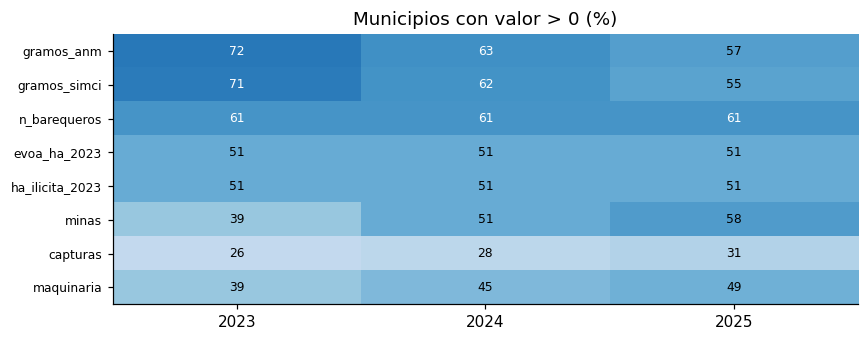

In [17]:
vars_cob = ["gramos_anm", "gramos_simci", "n_barequeros", "evoa_ha_2023", "ha_ilicita_2023", "minas", "capturas", "maquinaria"]
cob = panel.groupby("anio")[vars_cob].apply(lambda d: d.notna().mean() * 100).round(0); pos = panel.groupby("anio")[vars_cob].apply(lambda d: (d > 0).mean() * 100).round(0)
print("Dato disponible (%) — todo 100 por construcción: las ausencias son ceros estructurales"); display(cob.T)
print("Municipios con valor > 0 (%):"); display(pos.T)
mv = pd.DataFrame({"nulos": panel.isna().sum(), "pct_nulos": (panel.isna().mean() * 100).round(1), "ceros": (panel.select_dtypes("number") == 0).sum(), "pct_ceros": ((panel.select_dtypes("number") == 0).mean() * 100).round(1)})
print("Nulos y ceros por variable (municipio-años 2023–2025):"); display(mv[(mv.nulos > 0) | (mv.ceros > 0)].sort_values(["pct_nulos", "pct_ceros"], ascending=False))
print("Lectura: los NaN son cocientes sin denominador (share sin gramos, ratio sin inscritos, share ilícita sin huella, variación sin huella 2021); todo lo demás es cero administrativo.")
fig, ax = plt.subplots(figsize=(8, 3.2)); v = pos.T.values; ax.imshow(v, cmap="Blues", vmin=0, vmax=100, aspect="auto"); ax.grid(False)
ax.set_xticks(range(3)); ax.set_xticklabels(ANIOS); ax.set_yticks(range(len(vars_cob))); ax.set_yticklabels(vars_cob, fontsize=8); ax.set_title("Municipios con valor > 0 (%)")
for i in range(v.shape[0]):
    for j in range(v.shape[1]):
        ax.text(j, i, f"{v[i, j]:.0f}", ha="center", va="center", fontsize=8, color="white" if v[i, j] > 60 else "black")
plt.tight_layout(); plt.show()

### 9.2 Estadísticas descriptivas, distribuciones y valores extremos

Casi todas las variables son cantidades o conteos con cola larga, así que se describen también en escala logarítmica. Los valores extremos se buscan con un z robusto (mediana y desviación absoluta mediana) sobre `log10` de los valores positivos, que no se deja arrastrar por los municipios grandes. Al final se muestran las descriptivas por tipo predominante, que es la clasificación que el análisis de conglomerados tendrá que afinar.

,n,nulos,ceros,media,desv_est,cv,min,p5,p25,mediana,p75,p95,max,asimetria,curtosis
gramos_anm,591.00,0.00,213.00,"286,326.95","1,205,686.51",4.21,0.00,0.00,0.00,"1,769.24","61,401.86","1,187,625.32","15,381,919.90",7.54,68.52
regalias_cop,591.00,0.00,203.00,"2,662,362,946.49","11,707,217,557.80",4.40,0.00,0.00,0.00,"24,178,700.85","753,652,814.91","11,903,273,706.18","144,164,527,912.64",8.52,83.17
g_titulos,591.00,0.00,409.00,"130,778.01","760,936.10",5.82,0.00,0.00,0.00,0.00,"1,850.43","281,167.90","8,746,438.50",8.54,80.43
g_barequeros,591.00,0.00,337.00,"144,213.28","849,462.01",5.89,0.00,0.00,0.00,0.00,"8,612.45","545,911.72","12,953,353.09",11.62,152.18
share_barequeo,372.00,219.00,118.00,0.55,0.47,0.86,0.00,0.00,0.00,0.81,1.00,1.00,1.00,-0.18,-1.89
n_barequeros,591.00,0.00,231.00,367.50,"2,287.97",6.23,0.00,0.00,0.00,4.00,38.00,"1,171.50","29,209.00",10.77,128.67
ratio_tope_bareq,360.00,231.00,171.00,4.15,23.72,5.72,0.00,0.00,0.00,0.02,0.87,15.64,365.25,11.60,159.14
evoa_ha_2023,591.00,0.00,288.00,533.30,"1,394.90",2.62,0.00,0.00,0.00,4.51,203.17,"2,919.19","8,668.76",3.65,14.08
ha_ilicita_2023,591.00,0.00,288.00,404.22,"1,026.68",2.54,0.00,0.00,0.00,3.08,173.24,"2,049.94","6,351.12",3.60,13.75
share_ilicita_2023,303.00,288.00,0.00,0.85,0.23,0.27,0.02,0.42,0.73,0.97,1.00,1.00,1.00,-1.83,3.10


Descriptivas sobre valores > 0, en log10:


,n,media,desv_est,mediana,p5,p95,asimetria,curtosis
gramos_anm,378.00,4.33,1.30,4.44,1.95,6.31,-0.22,-0.62
g_titulos,182.00,4.35,1.15,4.30,2.37,6.39,0.11,-0.39
g_barequeros,254.00,4.15,1.38,4.32,1.80,6.14,-0.23,-0.93
n_barequeros,360.00,1.48,0.99,1.36,0.00,3.27,0.60,-0.00
evoa_ha_2023,303.00,2.30,0.91,2.29,0.86,3.74,-0.05,-1.01
minas,291.00,0.84,0.59,0.78,0.00,1.91,0.39,-0.48
capturas,168.00,0.79,0.44,0.78,0.00,1.52,0.05,-0.51
maquinaria,262.00,0.71,0.56,0.65,0.00,1.67,0.53,-0.39


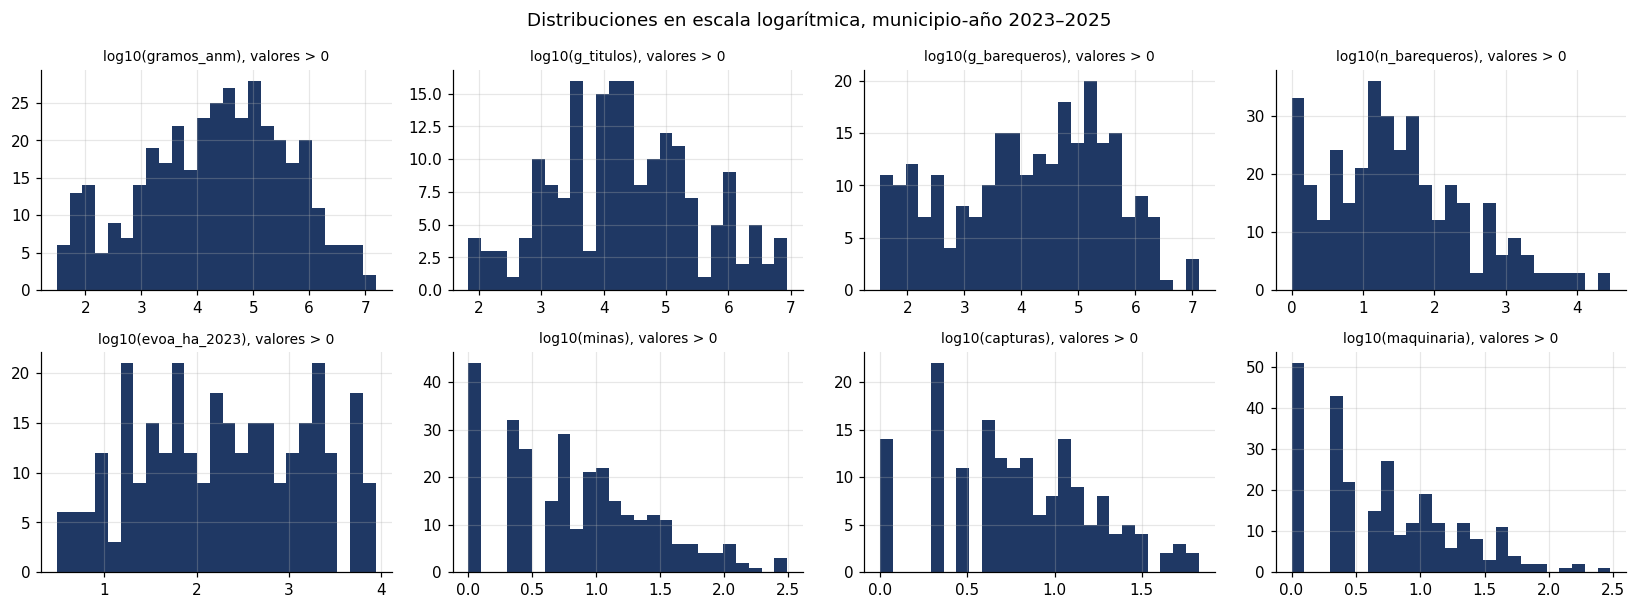

Valores extremos por z robusto (> 3,5 sobre log10 de valores > 0, ambas colas):
  gramos_anm: 0 de 378 municipio-años
  g_barequeros: 0 de 254 municipio-años
  n_barequeros: 0 de 360 municipio-años
  evoa_ha_2023: 0 de 303 municipio-años
  ratio_tope_bareq: 1 de 189 municipio-años → ['Mutata']

Descriptivas por tipo predominante (medianas, municipio-año):


,municipios,gramos_med,gramos_total_t,share_bareq_med,evoa_2023_med,share_ilicita_med,n_bareq_med,minas_med,maquinaria_med
tipo_predominante,,,,,,,,,
aluvión con barequeo,96,"3,924.61",81.79,1.00,0.00,0.92,9.00,0.00,0.00
aluvión con títulos,12,"499,851.48",47.47,0.00,"1,517.36",0.74,17.50,0.50,2.00
huella sin declaración,31,0.00,0.00,NaN,69.59,1.00,0.00,0.00,1.00
otros,17,"7,426.28",5.51,0.00,17.11,0.87,1.00,1.00,0.00
registro sin volumen ni huella,6,0.00,0.00,NaN,0.00,NaN,0.00,0.00,0.00
veta / títulos,35,"14,518.28",34.45,0.00,0.00,0.94,2.00,2.00,0.00


Perfiles citados en 1.3 (participación de títulos y barequeros en el trienio, %):


,g_titulos,g_barequeros
municipio,,
Buritica,100.00,0.00
Caucasia,7.70,91.90
Segovia,96.10,3.90


In [18]:
cols_desc = ["gramos_anm", "regalias_cop", "g_titulos", "g_barequeros", "share_barequeo", "n_barequeros", "ratio_tope_bareq", "evoa_ha_2023", "ha_ilicita_2023", "share_ilicita_2023", "minas", "capturas", "maquinaria"]
desc = tabla_resumen(panel, cols_desc); display(desc)
print("Descriptivas sobre valores > 0, en log10:")
display(pd.concat([resumen_num(np.log10(panel.loc[panel[c_] > 0, c_]), c_) for c_ in ["gramos_anm", "g_titulos", "g_barequeros", "n_barequeros", "evoa_ha_2023", "minas", "capturas", "maquinaria"]], axis=1).T[["n", "media", "desv_est", "mediana", "p5", "p95", "asimetria", "curtosis"]])
fig, axes = plt.subplots(2, 4, figsize=(15, 5.6))
for ax, c_ in zip(axes.ravel(), ["gramos_anm", "g_titulos", "g_barequeros", "n_barequeros", "evoa_ha_2023", "minas", "capturas", "maquinaria"]):
    ax.hist(np.log10(panel.loc[panel[c_] > 0, c_]), bins=25, color=AZUL); ax.set_title(f"log10({c_}), valores > 0", fontsize=9)
plt.suptitle("Distribuciones en escala logarítmica, municipio-año 2023–2025"); plt.tight_layout(); plt.show()

print("Valores extremos por z robusto (> 3,5 sobre log10 de valores > 0, ambas colas):")
for c_ in ["gramos_anm", "g_barequeros", "n_barequeros", "evoa_ha_2023", "ratio_tope_bareq"]:
    s = np.log10(panel.loc[panel[c_] > 0, c_]); m = extremos_mad(s); print(f"  {c_}: {m.sum()} de {len(s)} municipio-años" + (f" → {panel.loc[m[m].index, 'municipio'].unique().tolist()[:8]}" if m.sum() else ""))
print("\nDescriptivas por tipo predominante (medianas, municipio-año):")
display(panel.groupby("tipo_predominante").agg(municipios=("codigo_dane", "nunique"), gramos_med=("gramos_anm", "median"), gramos_total_t=("gramos_anm", lambda s: s.sum() / 1e6), share_bareq_med=("share_barequeo", "median"),
                                                 evoa_2023_med=("evoa_ha_2023", "median"), share_ilicita_med=("share_ilicita_2023", "median"), n_bareq_med=("n_barequeros", "median"), minas_med=("minas", "median"), maquinaria_med=("maquinaria", "median")).round(2))
print("Perfiles citados en 1.3 (participación de títulos y barequeros en el trienio, %):")
chk = panel[panel.municipio.isin(["Buritica", "Segovia", "Caucasia"])].groupby("municipio")[["g_titulos", "g_barequeros", "gramos_simci"]].sum()
display((chk[["g_titulos", "g_barequeros"]].div(chk.gramos_simci, axis=0) * 100).round(1))
cifra("1.3", "Buriticá: % títulos 2023–2025", 100, chk.loc["Buritica", "g_titulos"] / chk.loc["Buritica", "gramos_simci"] * 100, abs_tol=0.5)
cifra("1.3", "Segovia: % títulos 2023–2025", 96, chk.loc["Segovia", "g_titulos"] / chk.loc["Segovia", "gramos_simci"] * 100, abs_tol=0.5)
cifra("1.3", "Caucasia: % barequeros 2023–2025", 92, chk.loc["Caucasia", "g_barequeros"] / chk.loc["Caucasia", "gramos_simci"] * 100, abs_tol=0.5)
for n, d in [("Zaragoza", 2.5), ("Nechí", 0.2)]:
    cifra("1.3", f"{n}: declaración 2023–2025 (t)", d, panel.loc[panel.municipio.apply(normaliza) == normaliza(n), "gramos_anm"].sum() / 1e6, abs_tol=0.051)

### 9.3 Correlaciones

Se usa Spearman, por rangos, porque las variables son muy asimétricas y Pearson quedaría dominada por Caucasia y Buriticá. Es una primera lectura de las relaciones entre familias; no es un modelo.

,gramos_anm,regalias_cop,g_titulos,g_barequeros,share_barequeo,n_barequeros,ratio_tope_bareq,evoa_ha_2023,share_ilicita_2023,minas,capturas,maquinaria
gramos_anm,1.00,0.98,0.61,0.71,-0.11,0.44,0.64,0.30,-0.50,0.14,0.05,0.11
regalias_cop,0.98,1.00,0.61,0.69,-0.11,0.43,0.63,0.30,-0.51,0.14,0.05,0.11
g_titulos,0.61,0.61,1.00,0.10,-0.70,0.24,0.09,0.17,-0.45,0.21,0.16,0.13
g_barequeros,0.71,0.69,0.10,1.00,0.65,0.46,0.92,0.33,-0.35,0.05,-0.03,0.13
share_barequeo,-0.11,-0.11,-0.70,0.65,1.00,0.13,0.60,0.03,0.30,-0.17,-0.16,-0.02
n_barequeros,0.44,0.43,0.24,0.46,0.13,1.00,0.28,0.36,-0.33,0.17,0.09,0.21
ratio_tope_bareq,0.64,0.63,0.09,0.92,0.60,0.28,1.00,0.34,-0.24,-0.01,-0.09,0.08
evoa_ha_2023,0.30,0.30,0.17,0.33,0.03,0.36,0.34,1.00,-0.48,0.05,-0.04,0.34
share_ilicita_2023,-0.50,-0.51,-0.45,-0.35,0.30,-0.33,-0.24,-0.48,1.00,-0.13,-0.05,-0.09
minas,0.14,0.14,0.21,0.05,-0.17,0.17,-0.01,0.05,-0.13,1.00,0.40,0.58


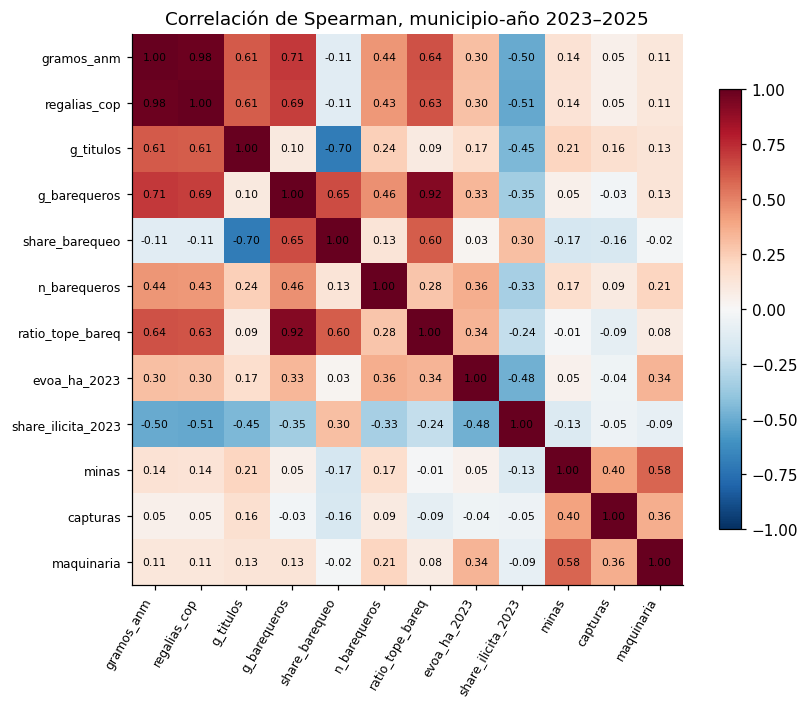

In [19]:
cc = ["gramos_anm", "regalias_cop", "g_titulos", "g_barequeros", "share_barequeo", "n_barequeros", "ratio_tope_bareq", "evoa_ha_2023", "share_ilicita_2023", "minas", "capturas", "maquinaria"]
corr = panel[cc].corr(method="spearman"); display(corr.round(2))
fig, ax = plt.subplots(figsize=(8, 6.5)); im = ax.imshow(corr.values, cmap="RdBu_r", vmin=-1, vmax=1); ax.grid(False)
ax.set_xticks(range(len(cc))); ax.set_xticklabels(cc, rotation=60, ha="right", fontsize=8); ax.set_yticks(range(len(cc))); ax.set_yticklabels(cc, fontsize=8)
for i in range(len(cc)):
    for j in range(len(cc)):
        ax.text(j, i, f"{corr.values[i, j]:.2f}", ha="center", va="center", fontsize=7)
plt.colorbar(im, ax=ax, shrink=0.8); ax.set_title("Correlación de Spearman, municipio-año 2023–2025"); plt.tight_layout(); plt.show()

### 9.4 Archivos de salida

In [20]:
DICC = pd.DataFrame([
    ("codigo_dane", "llave", "DANE", "código de municipio, 5 dígitos", "—"), ("municipio", "llave", "ANM/EVOA/RUCOM", "nombre", "—"), ("departamento", "llave", "DANE", "departamento (2 primeros dígitos)", "—"), ("anio", "llave", "—", "año", "2023–2025"),
    ("gramos_anm", "respuesta", "ANM r85m-vv6c", "producción declarada, gramos (suma de proyectos y trimestres)", "sin registro = 0"), ("regalias_cop", "respuesta / económicos", "ANM", "regalías liquidadas, COP corrientes", "sin registro = 0"),
    ("n_trimestres", "respuesta", "ANM", "trimestres con registro en el año (0–4)", "sin registro = 0"), ("precio_usd_onza", "económicos", "UPME–LBMA", "precio promedio anual, USD/oz troy", "—"), ("trm", "económicos", "SFC 32sa-8pi3", "TRM promedio anual", "—"),
    ("precio_cop_gramo", "económicos", "derivada", "precio_usd_onza × trm / 31,1035", "—"), ("g_titulos", "institucionales", "SIMCI", "gramos declarados por títulos mineros", "ausente = 0"), ("g_barequeros", "institucionales", "SIMCI", "gramos declarados por barequeros", "ausente = 0"),
    ("g_otros", "institucionales", "SIMCI", "ARE, chatarreros, solicitudes de legalización, subcontratos", "ausente = 0"), ("gramos_simci", "institucionales", "SIMCI", "suma de los tres anteriores", "ausente = 0"),
    ("share_barequeo", "institucionales", "derivada", "g_barequeros / gramos_simci", "NaN si gramos_simci = 0"), ("share_titulos", "institucionales", "derivada", "g_titulos / gramos_simci", "NaN si gramos_simci = 0"),
    ("n_barequeros", "institucionales", "RUCOM 6xd6-hsen", "mineros de subsistencia inscritos (padrón vigente)", "invariante; sin inscritos = 0"), ("tope_bareq_g", "institucionales", "derivada", "n_barequeros × 420 g (Res. 40103/2017)", "0 sin inscritos"),
    ("ratio_tope_bareq", "institucionales", "derivada", "g_barequeros / tope_bareq_g", "NaN sin inscritos"), ("bareq_sin_inscritos", "institucionales", "derivada", "1 si declara barequeo sin inscritos", "—"),
    ("evoa_ha_2023", "estructurales", "EVOA SIMCI", "huella aluvial 2023, ha (invariante)", "sin huella = 0"), ("evoa_ha_prom_2021_2023", "estructurales", "EVOA SIMCI", "promedio 2021–2023, ha", "sin huella = 0"),
    ("ha_permisos_2023", "estructurales", "EVOA", "huella con permisos técnicos 2023", "0"), ("ha_transito_2023", "estructurales", "EVOA", "huella en tránsito a la legalidad 2023", "0"), ("ha_ilicita_2023", "estructurales", "EVOA", "huella de explotación ilícita 2023", "0"),
    ("share_ilicita_2023", "estructurales", "derivada", "ha_ilicita_2023 / evoa_ha_2023", "NaN sin huella"), ("var_huella_2021_2023_pct", "estructurales", "derivada", "variación de la huella 2021→2023, %", "NaN sin huella 2021"),
    ("explotador_dominante", "estructurales", "derivada", "figura con más gramos en el trienio", "'sin declaración'"), ("tipo_predominante", "estructurales", "derivada", "clasificación descriptiva (ver sección 9)", "—"),
    ("minas", "seguridad", "MinDefensa", "minas intervenidas en el año", "sin eventos = 0"), ("capturas", "seguridad", "MinDefensa", "capturas por explotación ilícita en el año", "sin eventos = 0"), ("maquinaria", "seguridad", "MinDefensa", "unidades de maquinaria incautada en el año", "sin eventos = 0"),
], columns=["variable", "familia", "fuente", "definicion", "regla_de_ausencia"])
panel.to_csv(SAL / "panel_municipal_2023_2025.csv", index=False); pq.to_csv(SAL / "panel_municipal_trimestral_2023_2025.csv", index=False); DICC.to_csv(SAL / "panel_municipal_2023_2025_diccionario.csv", index=False)
desc.to_csv(SAL / "caracterizacion_descriptivas_2023_2025.csv"); mv.to_csv(SAL / "caracterizacion_valores_perdidos_2023_2025.csv")
print("Guardado en", SAL); display(DICC)

Guardado en /sessions/rcw-01sle5ke1veu8xvtm3ydfnw6/mnt/Tesis /BDATOS-ORO/06_panel


,variable,familia,fuente,definicion,regla_de_ausencia
0,codigo_dane,llave,DANE,"código de municipio, 5 dígitos",—
1,municipio,llave,ANM/EVOA/RUCOM,nombre,—
2,departamento,llave,DANE,departamento (2 primeros dígitos),—
3,anio,llave,—,año,2023–2025
4,gramos_anm,respuesta,ANM r85m-vv6c,"producción declarada, gramos (suma de proyectos y trimestres)",sin registro = 0
5,regalias_cop,respuesta / económicos,ANM,"regalías liquidadas, COP corrientes",sin registro = 0
6,n_trimestres,respuesta,ANM,trimestres con registro en el año (0–4),sin registro = 0
7,precio_usd_onza,económicos,UPME–LBMA,"precio promedio anual, USD/oz troy",—
8,trm,económicos,SFC 32sa-8pi3,TRM promedio anual,—
9,precio_cop_gramo,económicos,derivada,"precio_usd_onza × trm / 31,1035",—


## 10. Verificación de las cifras citadas en el documento

Cada cifra que la introducción y el marco teórico ya citan se recalculó desde las bases. Cuando el resultado dice `DIFIERE`, o el documento tiene una errata o hay una diferencia de criterio que hay que explicar en el texto.

In [21]:
tabla_cifras = pd.DataFrame(CIFRAS, columns=["seccion", "cifra", "documento", "calculado", "resultado"])
tabla_cifras.to_csv(SAL / "verificacion_cifras_documento.csv", index=False)
print(tabla_cifras.resultado.value_counts().to_dict()); pd.set_option("display.max_rows", 120); display(tabla_cifras)
check("Documento", "Las cifras citadas en el documento se reproducen desde las bases", (tabla_cifras.resultado == "coincide").all(), f"difieren: {tabla_cifras.loc[tabla_cifras.resultado != 'coincide', 'cifra'].tolist()}")

{'coincide': 66, 'DIFIERE': 2}


,seccion,cifra,documento,calculado,resultado
0,1.3 / Introducción,municipios que declararon en 2023,142.00,142.00,coincide
1,1.3 / Introducción,municipios que declararon en 2024,129.00,129.00,coincide
2,1.3 / Introducción,municipios que declararon en 2025,117.00,117.00,coincide
3,1.3,municipios distintos con declaración 2023–2025,167.00,167.00,coincide
4,1.3,producción declarada 2023 (t),61.30,61.33,coincide
5,1.3,producción declarada 2024 (t),56.70,56.73,coincide
6,1.3,producción declarada 2025 (t),51.20,51.15,coincide
7,1.3,máximo de la serie: 2012 (t),66.20,66.22,coincide
8,1.3,mínimo de la serie: 2018 (t),36.00,35.99,coincide
9,1.3,total del trienio (t),169.00,169.22,coincide


[REVISAR] Las cifras citadas en el documento se reproducen desde las bases — difieren: ['TRM promedio 2023', 'exportaciones de oro 7108 2023 (t)']


## 11. Tabla de validaciones

In [22]:
tabla_checks = pd.DataFrame(CHECKS, columns=["bloque", "verificacion", "resultado", "detalle"]); tabla_checks.to_csv(SAL / "caracterizacion_validaciones_2023_2025.csv", index=False)
print(tabla_checks.resultado.value_counts().to_dict()); display(tabla_checks)

{'OK': 34, 'REVISAR': 3}


,bloque,verificacion,resultado,detalle
0,Fuentes,Las siete fuentes de la Tabla 1 están en el repositorio,OK,0 faltantes
1,ANM,Conversión numérica sin pérdidas (gramos y regalías),OK,
2,ANM,codigo_dane de 5 dígitos con departamento válido,OK,
3,ANM,"Sin negativos, sin filas idénticas, un solo nombre por código",OK,
4,ANM,"2023, 2024 y 2025 completos (4 trimestres); 2026 parcial, excluido del análisis",OK,2026: 3 trimestres
5,Económicos,"Precio mensual continuo, sin repetidos ni nulos",OK,
6,Económicos,TRM mensual continua; solo el último mes parcial,OK,meses con < 15 días: ['2026-08']
7,Económicos,Todos los meses de precio tienen TRM; la ventana 2023–2025 está completa (36 meses),OK,
8,ANM,"Tasa implícita de regalía 2023–2025: mediana cerca de 0,032 y < 10 % de municipio-trimestres fuera de [0,016; 0,072]",OK,mediana = 0.0314; fuera de rango 63 de 1194 (5.3 %)
9,Institucionales,SIMCI: gramos numéricos sin nulos ni negativos; códigos de 5 dígitos válidos,OK,


## 12. Síntesis: qué dicen los datos y qué hay que decidir antes de la metodología

### Lo que está bien

Las siete fuentes de la Tabla 1 están en el repositorio (14 archivos) y se leen sin pérdida: ninguna conversión numérica produce `NaN`, no hay filas repetidas y todos los códigos son DANE de cinco dígitos con departamento válido. Las únicas excepciones son una fila de maquinaria con el código `760101`, que se excluye, y un municipio cuyo nombre cambia entre fuentes, Guadalajara de Buga frente a Buga, con el mismo código.

La ventana 2023–2025 está completa en todas las fuentes que varían en el tiempo: cuatro trimestres de la ANM cada año, 36 meses de precio y de TRM, doce meses de operativos cada año. La huella EVOA termina en 2023, como el documento ya advierte, y por eso entra como característica del municipio.

Las fuentes se validan entre sí. SIMCI reproduce el total de la ANM con una diferencia máxima de 0,82 t en la ventana; 36 municipio-años difieren en más de 1 kg y el mayor lo hace por 5,8 kg. EVOA cierra de municipio a departamento y a nación con 0,4 ha de diferencia, y permisos, tránsito e ilícita suman el total. El servicio ArcGIS reproduce lo publicado en datos.gov.co. Legiscomex reproduce Comtrade con una diferencia máxima de 0,055 %. La tasa implícita de regalía tiene mediana 0,0314, que es la esperada para un 4 % sobre un precio base del 80 %.

De las 68 cifras que cita el documento, 66 se reproducen desde las bases. Las dos que no coinciden son erratas del texto, no de los datos: la TRM promedio de 2023 es 4.324 pesos por dólar y el documento dice 4.424; las exportaciones de 2023 fueron 71,7 t y el documento dice 71,1. Las dos habían aparecido ya en la revisión de la versión 5 y siguen sin corregirse.

### Lo que hay que tener presente

El grano manda. La ANM trae varias filas por municipio-trimestre que se suman, y un municipio-año sin registro es una declaración de cero, no un dato perdido. En el panel no hay `NaN` salvo en los cocientes que se quedan sin denominador: la participación cuando no hay gramos, el cociente del tope cuando no hay inscritos, la proporción ilícita cuando no hay huella. Por eso `gramos_anm` tiene cero nulos y 36 % de ceros. Cuatro municipios tienen registro con 0 g durante todo el trienio, es decir, pagan regalías sin declarar volumen; el documento los cuenta entre los 167 que «declararon», y conviene decirlo.

El universo quedó en 197 municipios: 167 con registro de declaración, 101 con huella en 2023, 71 con las dos cosas y 30 con huella y sin declaración, que es el perfil que el documento anticipa. El panel municipio × año tiene 591 filas y 32 variables; el trimestral, 2.364 filas con producción, regalías, precio y operativos. Los operativos cubren 648 municipios en la ventana, 485 de ellos fuera del universo, porque la minería ilegal que persigue la fuerza pública no es solo de oro; entran como covariable.

Todas las variables municipales tienen cola larga (asimetría entre 3,6 y 11,6, curtosis entre 14 y 159, mediana de gramos municipio-año de 1,8 kg). En `log10` de los valores positivos las distribuciones quedan casi simétricas, con asimetría entre −0,2 y 0,6, y el z robusto solo marca a Mutatá en el cociente del tope. Antioquia reúne el 71 % del trienio y los diez primeros municipios otro 71 %. Cualquier método que use distancias o varianzas necesitará la transformación logarítmica o un escalado robusto.

La tipología descriptiva de partida reparte así los 197 municipios: 96 de aluvión con barequeo (82 t del trienio), 35 de veta o títulos (34 t), 12 de aluvión con títulos (47 t, mediana de huella de 1.517 ha), 31 con huella y sin declaración (mediana de 70 ha, toda sin figura de ley), 17 en otros y 6 con registro sin volumen. El análisis de conglomerados del objetivo 4 debe reemplazarla, no confirmarla.

Las anomalías de regalías se marcan y no se borran. 63 municipio-trimestres (5,3 %) tienen una tasa implícita fuera del rango 0,016–0,072. Segovia la tiene por debajo de 0,01 en los doce trimestres, con entre 1,4 y 1,9 t por trimestre, y Copacabana, Anorí, San Vicente y Bello muestran lo mismo de forma persistente. Eso apunta a un régimen de liquidación distinto, como el de los reconocimientos de propiedad privada, más que a un error de captura, y hay que preguntárselo a la ANM antes de usar las regalías como factor económico municipal. Mientras tanto `regalias_cop` y `gramos_anm` tienen correlación 0,98 y no aportan información distinta.

El contraste del barequeo con el tope legal reproduce exactamente las cifras del documento para 2023: 106 municipios con barequeo declarado, 42 por encima del tope de sus inscritos y 29 sin ningún inscrito; en 2024 son 83, 27 y 20. El cociente declarado/tope se correlaciona 0,92 con los gramos de barequeo porque el padrón es pequeño frente a la declaración; es una señal, no una medida de capacidad.

La huella es estructural y solo aluvial. 101 municipios la tienen en 2023 y el 75,8 % de esa superficie carece de figura de ley (la mediana municipal de la proporción ilícita es 0,97). Como EVOA no detecta veta, cualquier cociente de gramos por hectárea solo tiene sentido dentro de los municipios aluviales. La huella se correlaciona poco con los gramos (0,30) y la proporción ilícita se correlaciona en negativo (−0,50): donde la huella es más ilegal se declara menos.

Los operativos nacionales coinciden con el documento: 2.969, 5.247 y 6.151 minas intervenidas. Los tres indicadores van juntos entre sí (0,40 a 0,58) y poco con la producción declarada (0,21 como máximo); la maquinaria incautada sí acompaña a la huella (0,34). Junto con la producción, son la única familia con variación anual propia dentro de la ventana.

Las exportaciones quedan como señal nacional. La brecha entre lo exportado y lo declarado fue de 17 %, 23 % y 12 %. El microdato de 2023–2025, con 11.311 declaraciones de oro en bruto, tiene el domicilio del exportador en Bogotá en el 84 % de las filas y el origen en Antioquia en el 98 % de los kilos, lo que confirma que no puede bajar al municipio. El precio implícito mediano es 0,86 del LBMA, coherente con aleaciones; 20 declaraciones (0,18 %) se salen del rango; la razón social «PERSONA NATURAL» baja del 13 % en 2023 al 5 % en 2025; 33 filas tienen destino confidencial y las zonas francas reciben entre el 8 % y el 13 % del peso.

### Decisiones propuestas para la fase de metodología (para validar con los tutores)

Trabajar sobre `06_panel/panel_municipal_2023_2025.csv` (197 municipios × 3 años) y, para la producción, sobre `panel_municipal_trimestral_2023_2025.csv`; el diccionario está en `panel_municipal_2023_2025_diccionario.csv`. Los totales salen de la ANM, la composición por explotador de SIMCI (solo el consolidado anual), y la huella y su condición jurídica se usan como variables fijas del municipio (2023 y promedio 2021–2023). Los ceros estructurales se conservan y las cantidades se transforman a `log10(x + 1)` o a rangos antes de componentes principales, factorial y conglomerados; las asociaciones se miden con Spearman. No deben entrar juntas `regalias_cop` y `gramos_anm` (0,98) ni `evoa_ha_2023` y `ha_ilicita_2023`, que son la misma variable salvo por la proporción; queda por decidir si `ratio_tope_bareq` entra como variable o solo como señal. Las tasas de regalía anómalas se marcan, 2026 se excluye por incompleto, y en el documento hay que corregir la TRM de 2023 (4.324) y las exportaciones de 2023 (71,7 t).

Archivos escritos en `06_panel/`: `panel_municipal_2023_2025.csv`, `panel_municipal_trimestral_2023_2025.csv`, `panel_municipal_2023_2025_diccionario.csv`, `caracterizacion_descriptivas_2023_2025.csv`, `caracterizacion_valores_perdidos_2023_2025.csv`, `caracterizacion_validaciones_2023_2025.csv`, `verificacion_cifras_documento.csv`.

## 13. Qué análisis permiten estos datos y qué técnicas proponemos

### Lo que los datos no dejan hacer

Antes de escoger técnicas conviene decir qué cierran los datos, porque de ahí sale la elección.

La muestra es pequeña: 197 municipios, tres años, 591 municipio-años. Eso limita a unas diez variables por modelo, hace que los grupos de un agrupamiento se muevan de una corrida a otra y vuelve ruidosas las importancias de cualquier método de aprendizaje automático.

La variable de respuesta tiene un tercio de ceros y cola larga: la mediana municipal es 1,8 kg y el máximo 15 t; diez municipios reúnen el 71 % del total. Una regresión lineal o una correlación de Pearson sobre los gramos la deciden Caucasia y Buriticá.

Casi nada cambia en el tiempo dentro de la ventana. La huella termina en 2023 y solo mide aluvión; el padrón es de 2026; el tipo de minería es fijo. El precio cambia en el tiempo pero es igual para todos los municipios, así que en el panel anual toma tres valores y no se distingue del año. No hay panel longitudinal para los factores estructurales e institucionales: hay un corte transversal con tres lecturas de la respuesta.

Y la respuesta es un registro administrativo. Un cero no es ausencia de extracción, es ausencia de declaración; algunos municipios liquidan regalías con un régimen distinto (Segovia paga por debajo del 1 % en todos los trimestres); y el barequeo es un canal por el que entra oro de cualquier origen.

Lo que esto excluye: modelos con muchas variables, cualquier lectura causal, medir la producción ilegal, estimar cómo responde la huella al precio y llevar las exportaciones al municipio. Lo que deja en pie es describir, agrupar y medir asociaciones con métodos que toleren ceros y asimetría, y probar el precio solo en el panel trimestral.

### Las cuatro técnicas

**1. Análisis de correspondencias múltiples (ACM) para el objetivo 3.** Resume muchas variables en pocos ejes, igual que el ACP, pero recibe variables en categorías y trabaja con la frecuencia con que las categorías coinciden en los mismos municipios. Cada municipio queda descrito por una categoría en cada variable (huella ninguna, pequeña o grande; barequeo dentro del tope, sobre el tope o sin inscritos; explotador dominante; operativos ninguno, pocos o muchos) y la salida son dos cosas: un mapa donde las categorías que van juntas quedan cerca, y una coordenada por municipio.

Por qué aquí y no el ACP: los ceros dejan de ser un problema y pasan a ser la categoría que más interesa leer ("declara barequeo sin inscritos" es una de las tres señales de ilegalidad del documento); la cola larga desaparece porque Caucasia es "más de 1 t" igual que Segovia; y variables de naturaleza distinta (hectáreas, inscritos, capturas, proporciones) quedan en el mismo lenguaje sin decidir cómo se estandariza una frente a otra. El costo es que los cortes son una decisión nuestra: se escriben, se justifican con el negocio (420 g es el tope legal; 100 ha separa la huella marginal de la industrial) y se comprueba que el resultado no cambia si se mueven un poco. El ACP se corre como contraste, no como eje.

Supuestos del ACM y cómo se cumplen: variables categóricas con pocas categorías y ninguna rara (regla práctica: ninguna por debajo del 5 % de los municipios; la celda 13.1 lo comprueba); individuos independientes (se corre sobre los 197 municipios con valores del trienio, no sobre los 591 municipio-años); individuos suficientes frente a categorías (197 frente a unas 25); y carácter descriptivo, sin supuestos de normalidad, linealidad ni independencia entre variables. La inercia de los primeros ejes será baja, como siempre en ACM; se reporta corregida y se interpreta por las categorías que cargan en cada eje.

**2. Agrupamiento para el objetivo 4: Ward y c-medias difusas.** Sobre las coordenadas del ACM, el jerárquico de Ward muestra cuántos grupos tiene sentido cortar y el índice de silueta lo confirma. Luego c-medias difusas da a cada municipio un grado de pertenencia a cada perfil, que es lo que distingue a Caucasia (barequeo casi puro) de un municipio mixto. Validación: repetir el agrupamiento sobre muestras bootstrap y medir con Jaccard que los grupos se mantienen; cruzar con la tipología descriptiva de la sección 9. Decisión previa: los 30 municipios con huella y sin declaración y los 6 con registro sin volumen forman un grupo solos si entran; la propuesta es agrupar los 161 que declaran y tratarlos como perfil definido de antemano.

Describir cada perfil es repetir las descriptivas de la sección 9.2 por grupo: cuántos municipios, cuánto declaran, qué explotador domina, cuánta huella y qué tan ilícita, cuántos inscritos frente a lo declarado, cuántos operativos, en qué departamentos. De esa tabla sale el nombre de cada perfil, no al revés.

**3. Modelo en dos partes para el objetivo 5.** Como el 36 % de los municipio-años declara cero, se separan dos preguntas: una regresión logística para si el municipio declara, y una regresión sobre el logaritmo de los gramos para cuánto declara entre los que declaran. Errores agrupados por municipio, efectos de año, y estimación por perfil o con interacciones perfil × variable. Los coeficientes se leen como asociaciones.

**4. Panel trimestral para el precio.** Es el único lugar donde el precio varía dentro del municipio: `log(gramos + 1)` sobre el precio en pesos del trimestre, con efectos fijos de municipio, indicadores de trimestre del año y una interacción precio × perfil. Responde a las hipótesis 1 y 3 hasta donde doce trimestres de precio casi siempre al alza lo permiten; ese límite se dice de antemano.

### Lo que queda fuera y por qué

Bosque aleatorio y SHAP: con 591 filas añaden ruido y una capa de explicación que no hace falta defender. Análisis espacial: trabajo extra sin una pregunta del documento que lo exija. Análisis factorial clásico: repite el ACP. Extorsión y homicidio: se proponen en la reunión como decisión de los tutores, no se incorporan todavía; si entran, entran antes del ACM, porque cambian los perfiles.

### Orden y tiempos

Cortes y tabla de categorías (hecha abajo), ACM (una sesión), agrupamiento y descripción de perfiles (dos), modelo en dos partes (una), panel trimestral (una). Seis sesiones, que caben entre la entrega de metodología del 23 de octubre y los resultados preliminares del 13 de noviembre.

Referencias de las técnicas: Husson, Lê y Pagès (2017) para ACM; Ward (1963), Rousseeuw (1987) y Bezdek (1981) para el agrupamiento; Cragg (1971) para el modelo en dos partes.

### 13.1 Cortes propuestos para el ACM y conteo por categoría

Una fila por municipio con los valores del trienio, siete variables categorizadas con los cortes que se defienden en el texto, y el conteo de municipios en cada categoría. Ninguna categoría debería quedar por debajo del 5 % (unos diez municipios); si alguna queda, se funde con la vecina antes de correr el ACM. Eso ya pasó una vez: la huella con mayoría de figura de ley era rara separada por tamaño (6 grandes y 4 pequeñas), así que quedó como una sola categoría.

In [23]:
# Una fila por municipio con los valores del trienio
m = panel.groupby("codigo_dane").agg(municipio=("municipio", "first"), departamento=("departamento", "first"), gramos=("gramos_anm", "sum"),
                                     g_bareq=("g_barequeros", "sum"), n_bareq=("n_barequeros", "first"), evoa=("evoa_ha_2023", "first"),
                                     share_il=("share_ilicita_2023", "first"), dominante=("explotador_dominante", "first"),
                                     minas=("minas", "sum"), capturas=("capturas", "sum"), maquinaria=("maquinaria", "sum")).reset_index()

cat = m[["codigo_dane", "municipio", "departamento"]].copy()
cat["produccion"] = pd.cut(m.gramos, [-1, 0, 1e5, 1e6, np.inf], labels=["ninguna", "menos de 100 kg", "100 kg a 1 t", "más de 1 t"]).astype(str)
cat["explotador"] = m.dominante
def huella(r):
    # La huella mayormente con figura de ley es rara (10 municipios): se funde en una sola categoría sin distinguir tamaño
    if r.evoa == 0:
        return "sin huella"
    if r.share_il < 0.5:
        return "mayor parte con figura de ley"
    return ("pequeña" if r.evoa < 100 else "grande") + ", mayor parte ilícita"
cat["huella"] = m.apply(huella, axis=1)
tope3 = m.n_bareq * TOPE_BAREQ_G_ANIO * 3   # tope legal de los inscritos en los tres años
cat["barequeo_tope"] = np.select([m.g_bareq == 0, m.n_bareq == 0, m.g_bareq > tope3], ["no declara barequeo", "declara sin inscritos", "sobre el tope"], "dentro del tope")
cat["inscritos"] = pd.cut(m.n_bareq, [-1, 0, 50, np.inf], labels=["ninguno", "1 a 50", "más de 50"]).astype(str)
cat["minas_intervenidas"] = pd.cut(m.minas, [-1, 0, 10, np.inf], labels=["ninguna", "1 a 10", "más de 10"]).astype(str)
cat["maquinaria_incautada"] = np.where(m.maquinaria > 0, "alguna", "ninguna")

VARS_ACM = ["produccion", "explotador", "huella", "barequeo_tope", "inscritos", "minas_intervenidas", "maquinaria_incautada"]
frec = pd.concat([cat[v].value_counts().rename_axis("categoria").reset_index(name="municipios").assign(variable=v) for v in VARS_ACM])
frec["pct"] = (frec.municipios / len(cat) * 100).round(1)
frec = frec[["variable", "categoria", "municipios", "pct"]].reset_index(drop=True)
display(frec)
raras = frec[frec.pct < 5]
print(f"[{'OK' if len(raras) == 0 else 'REVISAR':7}] Ninguna categoría por debajo del 5 % de los municipios — "
      f"{len(raras)} raras: {raras[['variable', 'categoria', 'municipios']].values.tolist()}")
print(f"{len(cat)} municipios × {len(VARS_ACM)} variables = {len(frec)} categorías")

# Cruces que anticipan los perfiles
print("\nExplotador dominante × huella:"); display(pd.crosstab(cat.explotador, cat.huella))
print("Explotador dominante × barequeo frente al tope:"); display(pd.crosstab(cat.explotador, cat.barequeo_tope))
cat.to_csv(SAL / "acm_categorias_municipio_2023_2025.csv", index=False)
print("Guardado:", SAL / "acm_categorias_municipio_2023_2025.csv")

,variable,categoria,municipios,pct
0,produccion,menos de 100 kg,99,50.30
1,produccion,100 kg a 1 t,38,19.30
2,produccion,ninguna,34,17.30
3,produccion,más de 1 t,26,13.20
4,explotador,barequeros,96,48.70
5,explotador,títulos,47,23.90
6,explotador,sin declaración,37,18.80
7,explotador,otros,17,8.60
8,huella,sin huella,96,48.70
9,huella,"grande, mayor parte ilícita",54,27.40


[OK     ] Ninguna categoría por debajo del 5 % de los municipios — 0 raras: []
197 municipios × 7 variables = 24 categorías

Explotador dominante × huella:


huella,"grande, mayor parte ilícita",mayor parte con figura de ley,"pequeña, mayor parte ilícita",sin huella
explotador,,,,
barequeros,29,5,9,53
otros,6,2,2,7
sin declaración,11,0,20,6
títulos,8,3,6,30


Explotador dominante × barequeo frente al tope:


barequeo_tope,declara sin inscritos,dentro del tope,no declara barequeo,sobre el tope
explotador,,,,
barequeros,33,38,0,25
otros,1,3,9,4
sin declaración,0,0,37,0
títulos,4,6,30,7


Guardado: /sessions/rcw-01sle5ke1veu8xvtm3ydfnw6/mnt/Tesis /BDATOS-ORO/06_panel/acm_categorias_municipio_2023_2025.csv
